In [17]:
df.columns

Index(['large_double_bed', 'large_bed', 'single_bed', 'sofa_bed', 'double_bed',
       'small_double_bed', 'king_size_bed', 'futon_mattress', 'bunk_bed',
       'flexibility_score', 'sqm', 'bathroom_count', 'is_private_bathroom',
       'views', 'balcony-terrace', 'closet', 'air_conditioning', 'hair_dryer',
       'complimentary-bottled-water', 'bathtub', 'shower', 'refrigerator',
       'high-floor', 'dressing-room', 'ground-floor', 'private-pool',
       'top-floor', 'complimentary-instant-coffee', 'electric-blanket',
       'free-welcome-drink', 'low-floor', 'complimentary-tea',
       'coffee-tea-maker', 'hot-spring-access', 'bedroom_count',
       'price_option_price', 'adults_number', 'children_number', 'bãi_đậu_xe',
       'phòng_tập', 'wifi_miễn_phí', 'không_hoàn_tiền', 'miễn_phí_hủy',
       'vào_hồ_bơi_miễn_phí', 'đã_kèm_bữa_sáng', 'region'],
      dtype='object')

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# Load CSV file from local directory
# Change the file name below to match your CSV file name
# file_name = 'final_selected_data.csv'
file_name = "../../../Merge/final_selected_data.csv"

# Load the data into a pandas DataFrame
try:
    df = pd.read_csv(file_name, low_memory=False)
    print(f"✓ Successfully loaded '{file_name}' into a DataFrame.")
    print(f"  - Shape: {df.shape}")
except FileNotFoundError:
    print(f"❌ Error: File '{file_name}' not found!")
    print(f"   Please make sure the CSV file is in the same directory as this notebook.")
    print(f"   Or update the 'file_name' variable above with the correct path.")
except Exception as e:
    print(f"❌ Error loading CSV: {e}")
    
# Drop unnecessary columns
df.drop(columns=["room_type_id", "hotel_id", "room_room_type_name", "hotel_name", "hotel_address"], inplace=True, errors='ignore')

# Define boolean columns that need to be converted to binary (0/1) first
# These columns have True/NaN values and should be converted to 1/0
boolean_to_binary_cols = ['large_double_bed', 'large_bed', 'single_bed', 'sofa_bed', 'double_bed',
                          'small_double_bed', 'king_size_bed', 'futon_mattress', 'bunk_bed',
                          'is_private_bathroom', 'balcony-terrace', 'closet', 'air_conditioning', 
                          'hair_dryer', 'complimentary-bottled-water', 'bathtub', 'shower', 
                          'refrigerator', 'high-floor', 'dressing-room', 'ground-floor', 'private-pool',
                          'top-floor', 'complimentary-instant-coffee', 'electric-blanket', 
                          'free-welcome-drink', 'low-floor', 'complimentary-tea', 'coffee-tea-maker', 
                          'hot-spring-access', 'bãi_đậu_xe', 'phòng_tập', 'wifi_miễn_phí', 'không_hoàn_tiền', 
                          'miễn_phí_hủy', 'vào_hồ_bơi_miễn_phí', 'đã_kèm_bữa_sáng']

print("\n--- Step 1: Convert Boolean Columns to Binary (0/1) ---")
# Convert boolean columns to binary before processing
for col in boolean_to_binary_cols:
    if col in df.columns:
        # Convert True -> 1, False/NaN -> 0
        df[col] = df[col].fillna(False).astype(int)
        print(f"Converted '{col}' to binary (0/1).")
    else:
        print(f"Warning: Boolean column '{col}' not found in DataFrame.")

# Define categorical columns (excluding boolean columns that are now binary)
categorical_cols = ['views', 'region']
# Add the converted binary columns to categorical (they are now 0/1 but represent categories)
categorical_cols.extend(boolean_to_binary_cols)

# Define numerical columns
numerical_cols = ['flexibility_score', 'sqm', 'bathroom_count', 
                  'bedroom_count', 'price_option_price', 'adults_number', 
                  'children_number']

print("\n--- Step 2: Convert Categorical Columns to 'category' dtype ---")
# Convert categorical columns to 'category' dtype
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')
        print(f"Converted '{col}' to category type.")
    else:
        print(f"Warning: Categorical column '{col}' not found in DataFrame.")

print("\n--- Step 3: Convert Numerical Columns to Numeric Type ---")
# Attempt to convert numerical columns to a suitable numerical type, handling errors
for col in numerical_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"Converted '{col}' to numeric type (coerced errors).")
    else:
        print(f"Warning: Numerical column '{col}' not found in DataFrame.")

print("\n--- Identified Column Types ---")
print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

print("\n--- Step 4: Check Missing Values in Target Variable (price_option_price) ---")
# Check for missing values in the target variable
missing_price_count = df['price_option_price'].isna().sum()
total_rows = len(df)
missing_percentage = (missing_price_count / total_rows) * 100

print(f"Missing values in 'price_option_price': {missing_price_count} out of {total_rows} ({missing_percentage:.2f}%)")

if missing_price_count > 0:
    print("\n⚠️  WARNING: Target variable has missing values!")
    print("\nAnalysis of missing price_option_price:")
    missing_df = df[df['price_option_price'].isna()]
    # print(f"\nHotels with missing prices:")
    # print(missing_df['hotel_name'].value_counts().head(10))
    # print(f"\nRoom types with missing prices:")
    # print(missing_df['room_room_type_name'].value_counts().head(10))
    if 'region' in df.columns:
        print(f"\nRegions with missing prices:")
        print(missing_df['region'].value_counts())
    
    print("\n💡 RECOMMENDATION:")
    print("Since price_option_price is the target variable, you have two options:")
    print("1. Drop rows with missing prices (if acceptable for your analysis)")
    print("2. Impute missing prices (e.g., using median by hotel/region/room_type)")
    print("\nTo drop missing values, uncomment the line below:")
    print("# df = df.dropna(subset=['price_option_price'])")
else:
    print("✓ No missing values in target variable!")

print("\n--- DataFrame Info After Conversions ---")
df.info()

✓ Successfully loaded '../../../Merge/final_selected_data.csv' into a DataFrame.
  - Shape: (19520, 51)

--- Step 1: Convert Boolean Columns to Binary (0/1) ---
Converted 'large_double_bed' to binary (0/1).
Converted 'large_bed' to binary (0/1).
Converted 'single_bed' to binary (0/1).
Converted 'sofa_bed' to binary (0/1).
Converted 'double_bed' to binary (0/1).
Converted 'small_double_bed' to binary (0/1).
Converted 'king_size_bed' to binary (0/1).
Converted 'futon_mattress' to binary (0/1).
Converted 'bunk_bed' to binary (0/1).
Converted 'is_private_bathroom' to binary (0/1).
Converted 'balcony-terrace' to binary (0/1).
Converted 'closet' to binary (0/1).
Converted 'air_conditioning' to binary (0/1).
Converted 'hair_dryer' to binary (0/1).
Converted 'complimentary-bottled-water' to binary (0/1).
Converted 'bathtub' to binary (0/1).
Converted 'shower' to binary (0/1).
Converted 'refrigerator' to binary (0/1).
Converted 'high-floor' to binary (0/1).
Converted 'dressing-room' to binary (

## 1. Data Overview

Basic information about the dataset including shape, data types, and missing values.


In [2]:
print("--- DataFrame Shape ---")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n--- First 5 Rows of DataFrame ---")
display(df.head())

print("\n--- Column Names List ---")
print(df.columns.tolist())

print("\n--- Number of Missing Values Per Column ---")
print(df.isnull().sum())

--- DataFrame Shape ---
Rows: 19520
Columns: 46

--- First 5 Rows of DataFrame ---


,large_double_bed,large_bed,single_bed,sofa_bed,double_bed,small_double_bed,king_size_bed,futon_mattress,bunk_bed,flexibility_score,...,adults_number,children_number,bãi_đậu_xe,phòng_tập,wifi_miễn_phí,không_hoàn_tiền,miễn_phí_hủy,vào_hồ_bơi_miễn_phí,đã_kèm_bữa_sáng,region
0,1,0,0,0,0,0,0,0,0,1,...,2,0,1,0,1,0,1,0,0,Bà Rịa
1,0,1,0,0,0,0,0,0,0,1,...,2,0,1,0,1,0,1,0,0,Bà Rịa
2,0,1,0,0,0,0,0,0,0,1,...,4,2,1,0,1,0,1,0,0,Bà Rịa
3,0,1,0,0,0,0,0,0,0,1,...,2,0,1,0,0,0,1,0,0,Bà Rịa
4,1,0,1,0,0,0,0,0,0,2,...,2,0,0,0,1,0,0,0,0,Bình Dương



--- Column Names List ---
['large_double_bed', 'large_bed', 'single_bed', 'sofa_bed', 'double_bed', 'small_double_bed', 'king_size_bed', 'futon_mattress', 'bunk_bed', 'flexibility_score', 'sqm', 'bathroom_count', 'is_private_bathroom', 'views', 'balcony-terrace', 'closet', 'air_conditioning', 'hair_dryer', 'complimentary-bottled-water', 'bathtub', 'shower', 'refrigerator', 'high-floor', 'dressing-room', 'ground-floor', 'private-pool', 'top-floor', 'complimentary-instant-coffee', 'electric-blanket', 'free-welcome-drink', 'low-floor', 'complimentary-tea', 'coffee-tea-maker', 'hot-spring-access', 'bedroom_count', 'price_option_price', 'adults_number', 'children_number', 'bãi_đậu_xe', 'phòng_tập', 'wifi_miễn_phí', 'không_hoàn_tiền', 'miễn_phí_hủy', 'vào_hồ_bơi_miễn_phí', 'đã_kèm_bữa_sáng', 'region']

--- Number of Missing Values Per Column ---
large_double_bed                   0
large_bed                          0
single_bed                         0
sofa_bed                           0

## 2. Target Variable Analysis

Analysis of the target variable (price_option_price) including distribution and basic statistics.


--- Distribution of price_option_price ---


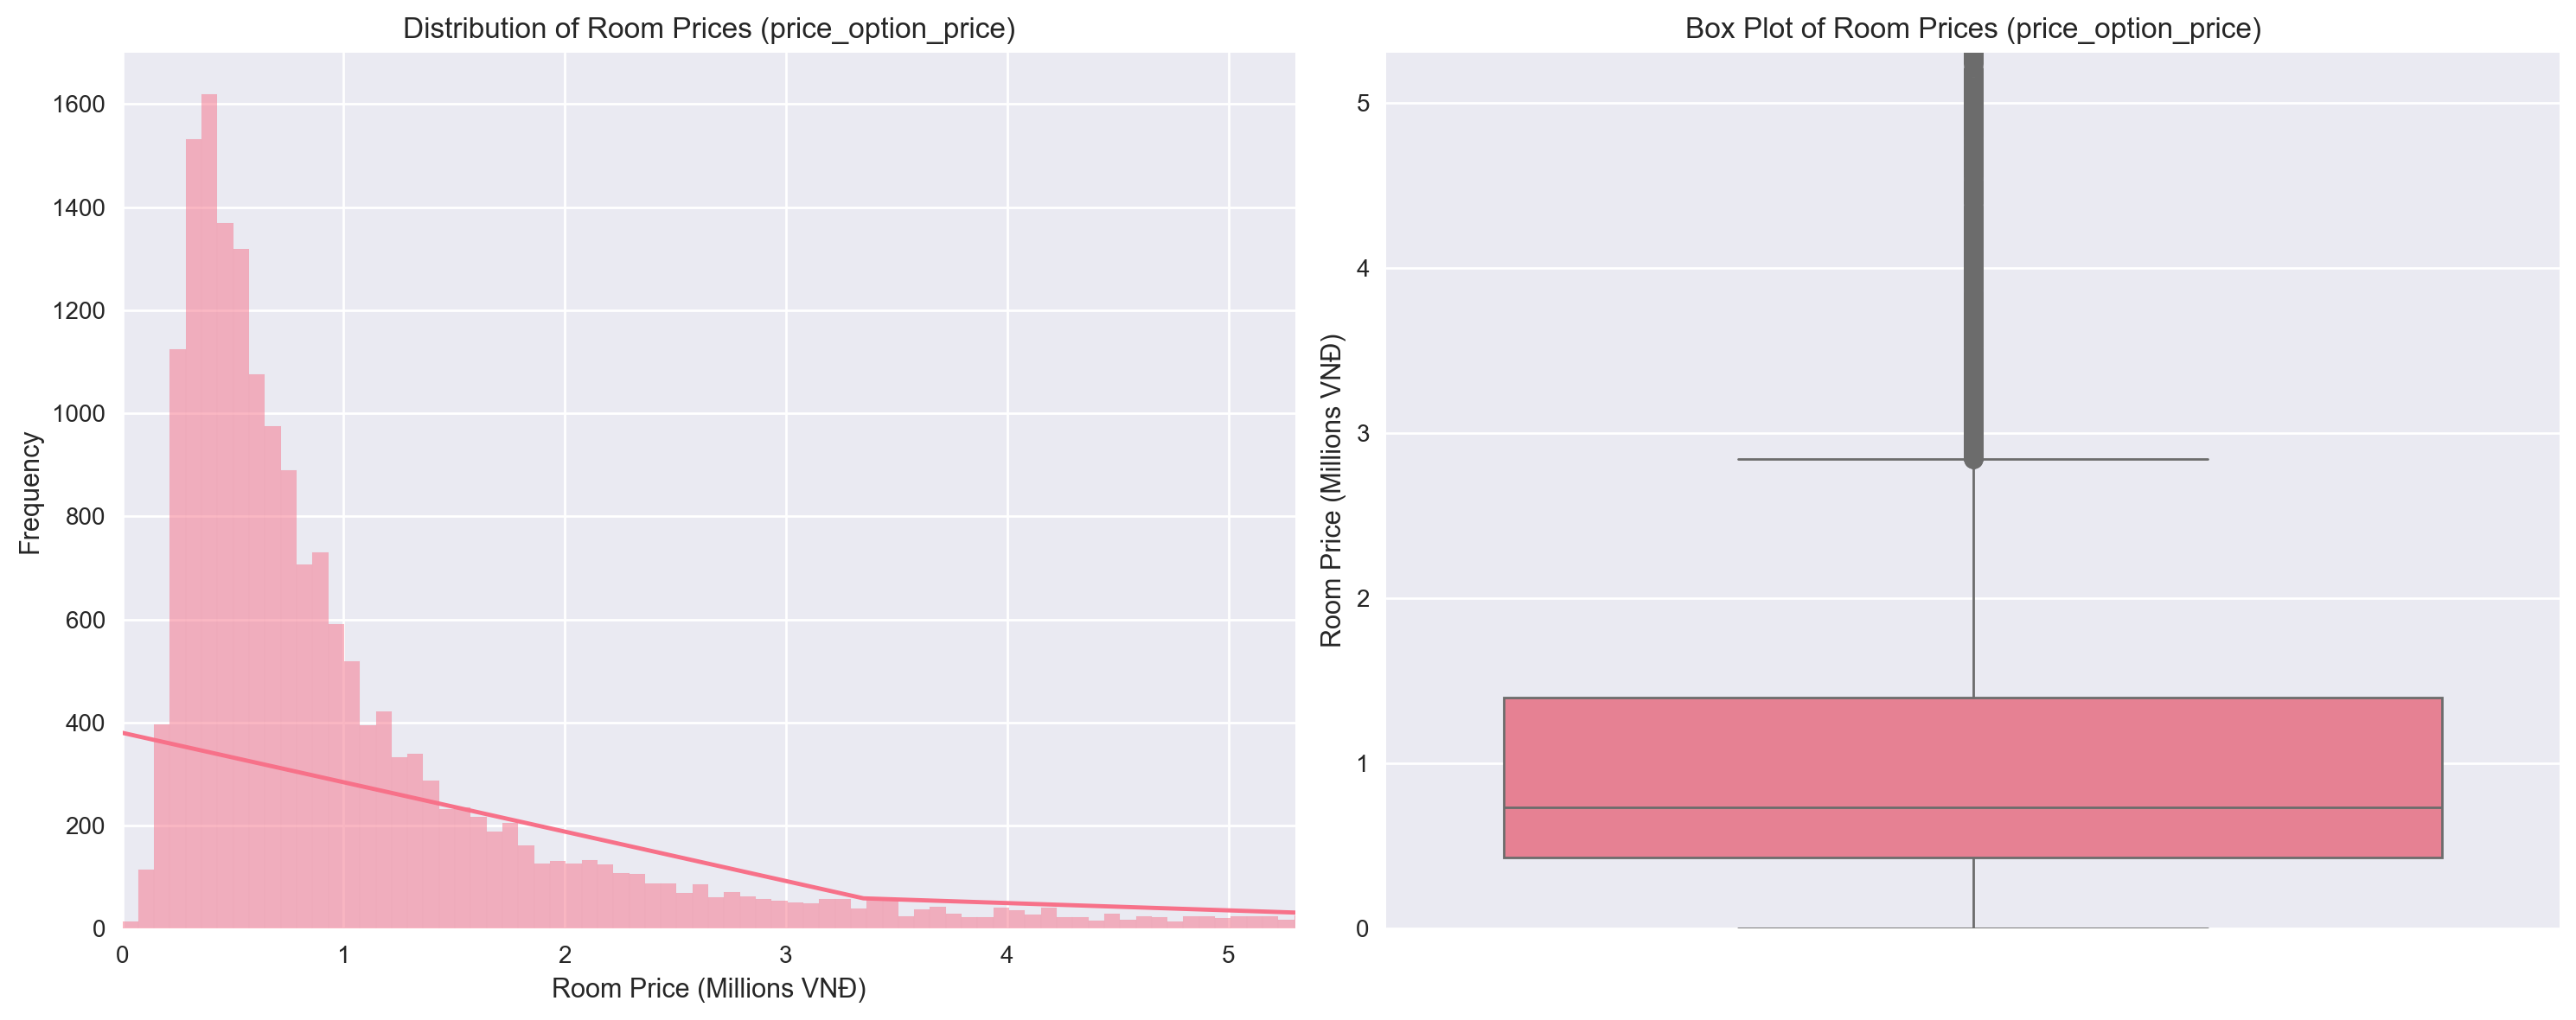


--- Basic Statistics for price_option_price ---


count        19,491
mean      1,567,054
std       5,910,918
min               0
25%         433,544
50%         735,294
75%       1,396,832
max     666,666,667
Name: price_option_price, dtype: float64

In [23]:
print("--- Distribution of price_option_price ---")

# Convert price to millions for better visualization
df_price = df['price_option_price'].dropna() / 1_000_000  # Convert to millions
# df_price_log = np.log1p(df['price_option_price'].dropna())


plt.figure(figsize=(15, 6), dpi=200)

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df_price, kde=True)
plt.title('Distribution of Room Prices (price_option_price)')
plt.xlabel('Room Price (Millions VNĐ)')
plt.ylabel('Frequency')
# Rescale x-axis to focus on main distribution (remove extreme outliers)
# Use 95th percentile to set reasonable x-axis limit
x_max = df_price.quantile(0.95)
plt.xlim(0, x_max)

# Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=df_price)
plt.title('Box Plot of Room Prices (price_option_price)')
plt.ylabel('Room Price (Millions VNĐ)')
# Rescale y-axis to focus on main distribution (remove extreme outliers)
y_max = df_price.quantile(0.95)
plt.ylim(0, y_max)

plt.tight_layout()
plt.show()

pd.set_option('display.float_format', '{:,.0f}'.format)
print("\n--- Basic Statistics for price_option_price ---")
display(df['price_option_price'].describe())

## 3. Price Analysis by Region

Geographic distribution of room prices across different regions.


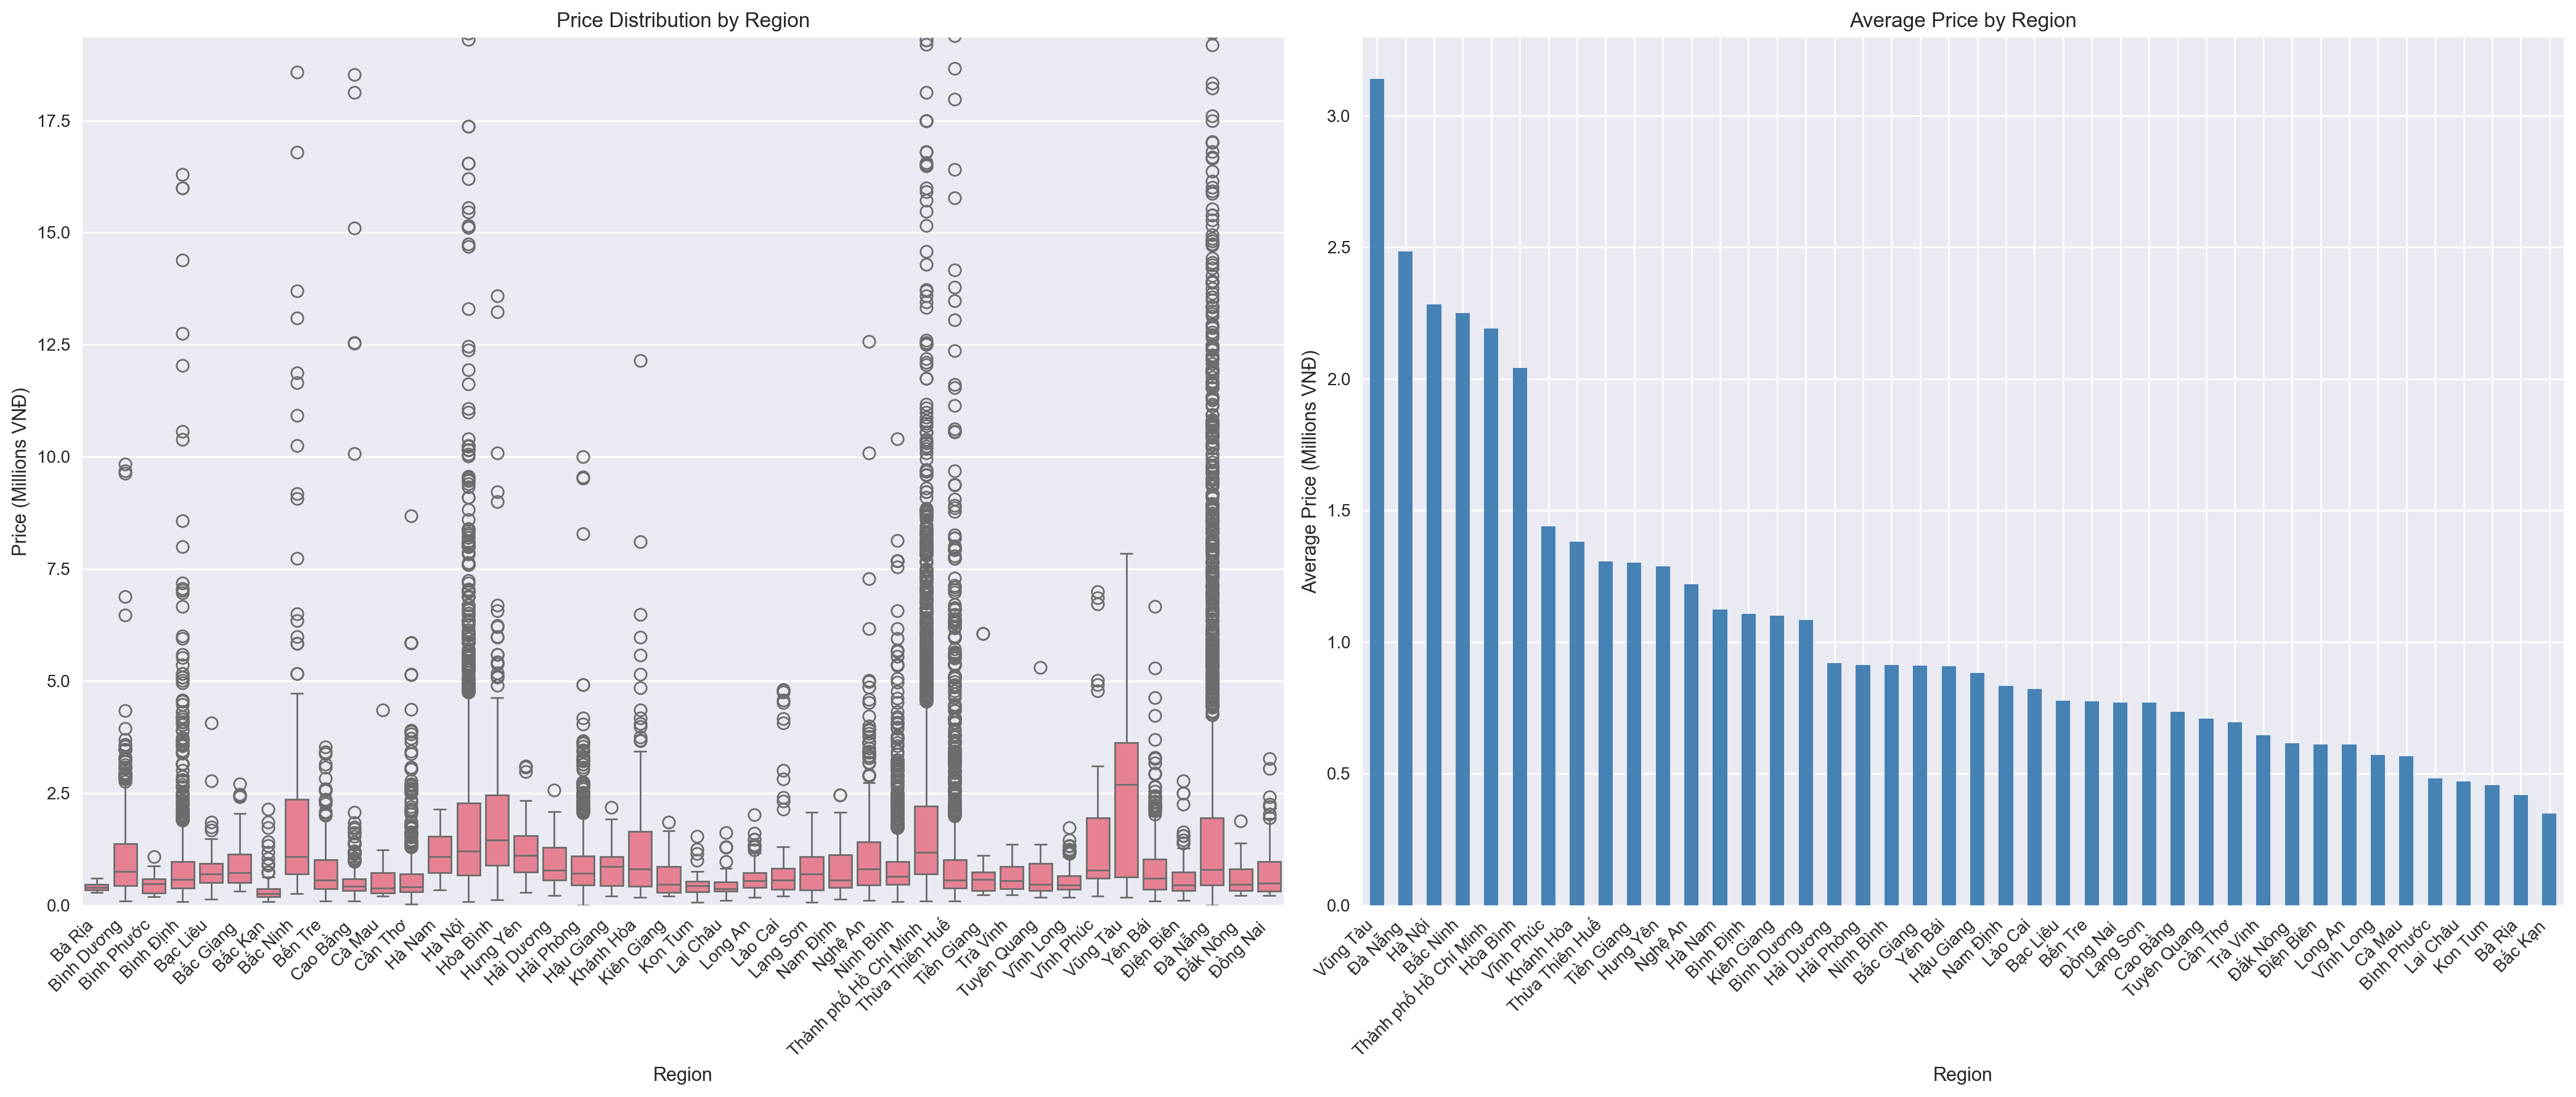


--- Average Price by Region (in VNĐ) ---


,Average Price (VNĐ)
region,
Vũng Tàu,"3,140,297"
Đà Nẵng,"2,485,402"
Hà Nội,"2,282,078"
Bắc Ninh,"2,249,136"
Thành phố Hồ Chí Minh,"2,190,755"
Hòa Bình,"2,041,672"
Vĩnh Phúc,"1,439,368"
Khánh Hòa,"1,381,869"
Thừa Thiên Huế,"1,306,476"


In [24]:
# Price Distribution by Region
if 'region' in df.columns and 'price_option_price' in df.columns:
    plt.figure(figsize=(21, 9), dpi=200)
    
    df_clean = df.dropna(subset=['price_option_price', 'region'])
    # Convert price to millions for better visualization
    df_clean_price = df_clean.copy()
    df_clean_price['price_millions'] = df_clean_price['price_option_price'] / 1_000_000
    
    # Box plot
    plt.subplot(1, 2, 1)
    sns.boxplot(data=df_clean_price, x='region', y='price_millions')
    plt.title('Price Distribution by Region')
    plt.xlabel('Region')
    plt.ylabel('Price (Millions VNĐ)')
    plt.xticks(rotation=45, ha='right')
    # Rescale y-axis to focus on main distribution (remove extreme outliers)
    y_max = df_clean_price['price_millions'].quantile(0.995)
    plt.ylim(0, y_max)
    
    # Bar plot - Average price by region
    plt.subplot(1, 2, 2)
    avg_price_by_region = df_clean.groupby('region')['price_option_price'].mean().sort_values(ascending=False) / 1_000_000
    avg_price_by_region.plot(kind='bar', color='steelblue')
    plt.title('Average Price by Region')
    plt.xlabel('Region')
    plt.ylabel('Average Price (Millions VNĐ)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    print("\n--- Average Price by Region (in VNĐ) ---")
    # Format the price column for better readability with thousand separators
    avg_price_df = (avg_price_by_region * 1_000_000).to_frame('Average Price (VNĐ)')
    avg_price_df['Average Price (VNĐ)'] = avg_price_df['Average Price (VNĐ)'].apply(lambda x: f"{x:,.0f}")
    display(avg_price_df)


## 3. Price vs Room Characteristics

Relationship between room area and price, and price distribution by area ranges.


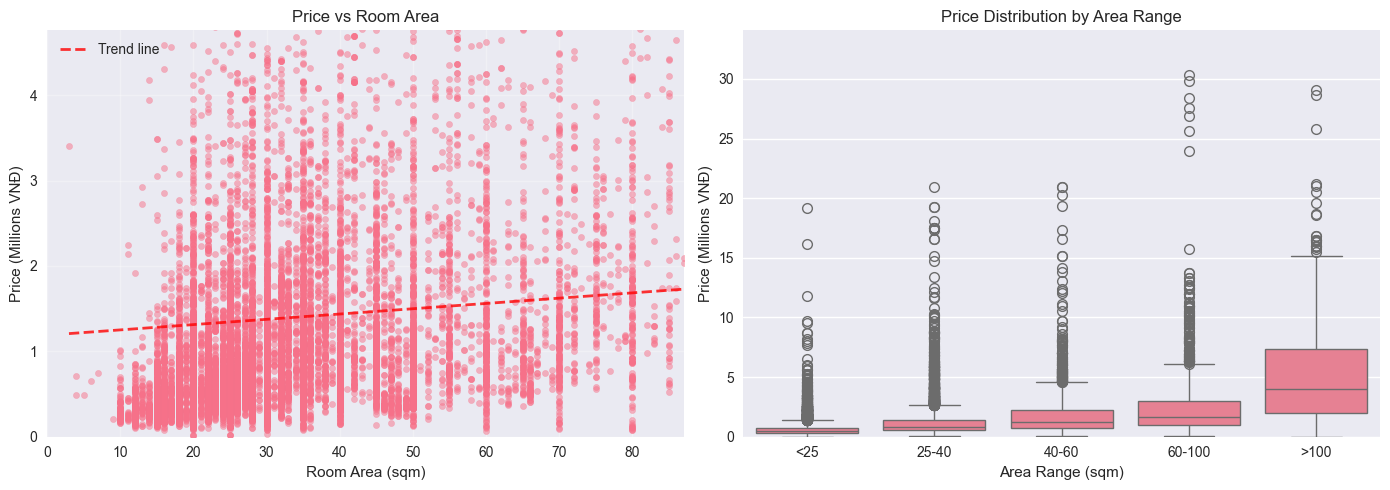


Correlation between sqm and price_option_price: 0.101


In [5]:
# Price vs Room Area (sqm) Relationship
if 'sqm' in df.columns and 'price_option_price' in df.columns:
    plt.figure(figsize=(14, 5))
    
    df_clean = df.dropna(subset=['price_option_price', 'sqm'])
    # Convert price to millions for better visualization
    df_clean_price = df_clean.copy()
    df_clean_price['price_millions'] = df_clean_price['price_option_price'] / 1_000_000
    
    # Scatter plot
    plt.subplot(1, 2, 1)
    plt.scatter(df_clean_price['sqm'], df_clean_price['price_millions'], alpha=0.5, s=20)
    plt.xlabel('Room Area (sqm)')
    plt.ylabel('Price (Millions VNĐ)')
    plt.title('Price vs Room Area')
    plt.grid(True, alpha=0.3)
    
    # Add trend line
    z = np.polyfit(df_clean_price['sqm'], df_clean_price['price_millions'], 1)
    p = np.poly1d(z)
    plt.plot(df_clean_price['sqm'].sort_values(), p(df_clean_price['sqm'].sort_values()), "r--", alpha=0.8, linewidth=2, label='Trend line')
    plt.legend()
    # Rescale x-axis and y-axis to focus on main distribution (remove extreme outliers)
    x_max = df_clean_price['sqm'].quantile(0.95)
    y_max = df_clean_price['price_millions'].quantile(0.95)
    plt.xlim(0, x_max)
    plt.ylim(0, y_max)
    
    # Box plot by area ranges
    plt.subplot(1, 2, 2)
    df_clean_price['area_range'] = pd.cut(df_clean_price['sqm'], bins=[0, 25, 40, 60, 100, 200], labels=['<25', '25-40', '40-60', '60-100', '>100'])
    sns.boxplot(data=df_clean_price, x='area_range', y='price_millions')
    plt.title('Price Distribution by Area Range')
    plt.xlabel('Area Range (sqm)')
    plt.ylabel('Price (Millions VNĐ)')
    # Rescale y-axis to focus on main distribution (remove extreme outliers)
    y_max_box = df_clean_price['price_millions'].quantile(0.9992)
    plt.ylim(0, y_max_box)
    
    plt.tight_layout()
    plt.show()
    
    # Correlation
    correlation = df_clean['sqm'].corr(df_clean['price_option_price'])
    print(f"\nCorrelation between sqm and price_option_price: {correlation:.3f}")


## 4. Correlation Analysis

Correlation heatmap showing relationships between numerical features.


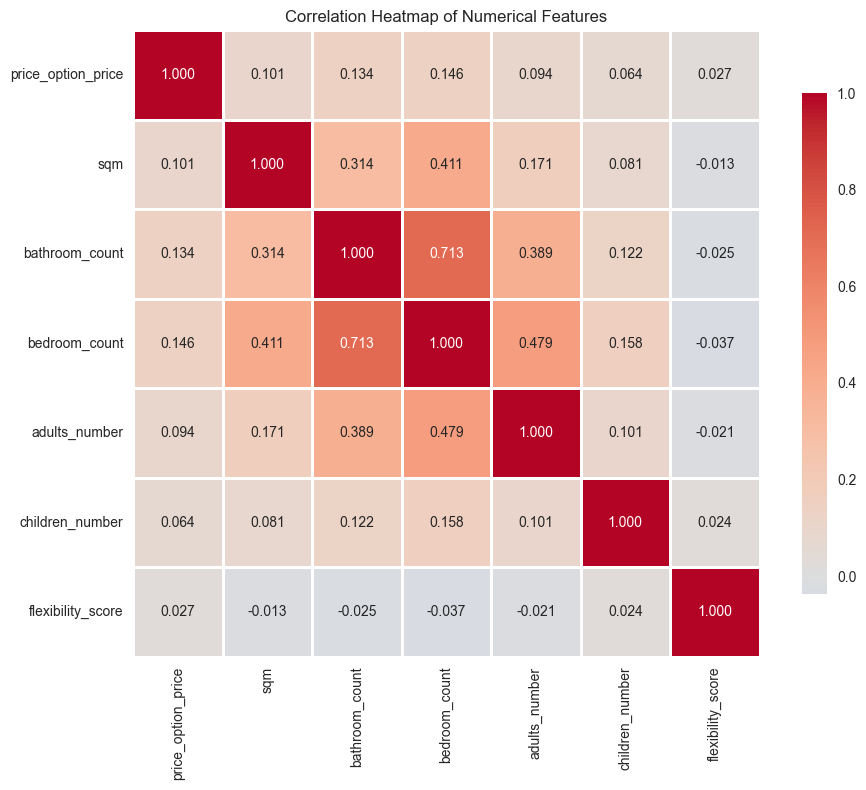


--- Correlation with Price (price_option_price) ---


,Correlation
price_option_price,1
bedroom_count,0
bathroom_count,0
sqm,0
adults_number,0
children_number,0
flexibility_score,0


In [6]:
# Correlation Heatmap for Numerical Features
numerical_for_corr = ['price_option_price', 'sqm', 'bathroom_count', 'bedroom_count', 
                       'adults_number', 'children_number', 'flexibility_score']

# Filter to only include columns that exist
# numerical_for_corr = numerical_cols
numerical_for_corr = [col for col in numerical_for_corr if col in df.columns]

if len(numerical_for_corr) > 1:
    plt.figure(figsize=(10, 8))
    correlation_matrix = df[numerical_for_corr].corr()
    
    sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Heatmap of Numerical Features')
    plt.tight_layout()
    plt.show()
    
    print("\n--- Correlation with Price (price_option_price) ---")
    if 'price_option_price' in correlation_matrix.columns:
        price_corr = correlation_matrix['price_option_price'].sort_values(ascending=False)
        display(price_corr.to_frame('Correlation'))


## 5. Amenities Impact Analysis

Analysis of how different amenities affect room prices.


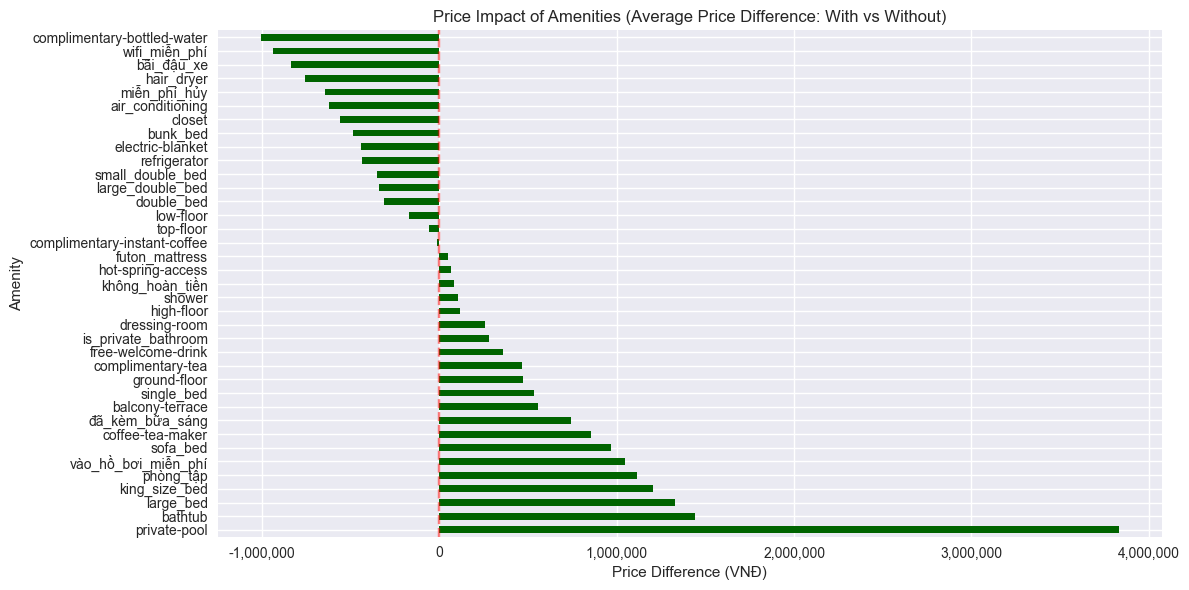


--- Amenity Impact on Price ---


,With,Without,Difference
private-pool,"5,193,706","1,361,805","3,831,901"
bathtub,"2,586,600","1,146,289","1,440,311"
large_bed,"2,569,859","1,240,764","1,329,095"
king_size_bed,"2,741,264","1,536,203","1,205,061"
phòng_tập,"2,564,919","1,449,638","1,115,281"
vào_hồ_bơi_miễn_phí,"2,580,181","1,535,153","1,045,029"
sofa_bed,"2,481,569","1,515,402","966,166"
coffee-tea-maker,"2,413,899","1,557,164","856,735"
đã_kèm_bữa_sáng,"2,176,125","1,435,412","740,713"
balcony-terrace,"1,911,999","1,353,073","558,926"


In [7]:
# Amenities Analysis - Impact on Price

amenity_cols = [
    col for col in categorical_cols
    if col in df.columns
    and col not in ['region', 'hotel_name', 'room_room_type_name', 'views']
    and set(df[col].dropna().unique()).issubset({0, 1})
]
# Filter to only include columns that exist
amenity_cols = [col for col in amenity_cols if col in df.columns]

if len(amenity_cols) > 0 and 'price_option_price' in df.columns:
    df_clean = df.dropna(subset=['price_option_price'])
    
    # Calculate average price with and without each amenity
    amenity_impact = {}
    for col in amenity_cols:
        if col in df_clean.columns:
            avg_with = df_clean[df_clean[col] == 1]['price_option_price'].mean()
            avg_without = df_clean[df_clean[col] == 0]['price_option_price'].mean()
            amenity_impact[col] = {
                'With': avg_with,
                'Without': avg_without,
                'Difference': avg_with - avg_without
            }
    
    if amenity_impact:
        impact_df = pd.DataFrame(amenity_impact).T.sort_values('Difference', ascending=False)
        
        plt.figure(figsize=(12, 6))
        impact_df['Difference'].plot(kind='barh', color='darkgreen')
        plt.title('Price Impact of Amenities (Average Price Difference: With vs Without)')
        plt.xlabel('Price Difference (VNĐ)')
        plt.ylabel('Amenity')
        plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
        # Format x-axis to avoid scientific notation
        plt.ticklabel_format(style='plain', axis='x')
        # Format x-axis labels with thousand separators
        ax = plt.gca()
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
        plt.tight_layout()
        plt.show()
        
        print("\n--- Amenity Impact on Price ---")
        display(impact_df)


---

# Part 2: Comprehensive Exploratory Data Analysis (EDA)

Based on the cleaned dataset, we will perform comprehensive EDA following a systematic approach:

1. **Univariate Analysis** - Distribution and frequency analysis for all variables
2. **Bivariate Analysis** - Relationships between pairs of variables  
3. **Multivariate Analysis** - Complex patterns across multiple variables
4. **Business Insights** - Key findings and actionable recommendations



## 1. Comprehensive Univariate Analysis

### 1.1 Distribution Analysis for ALL Numerical Columns

Analyze the distribution, skewness, and key statistics for every numerical feature.


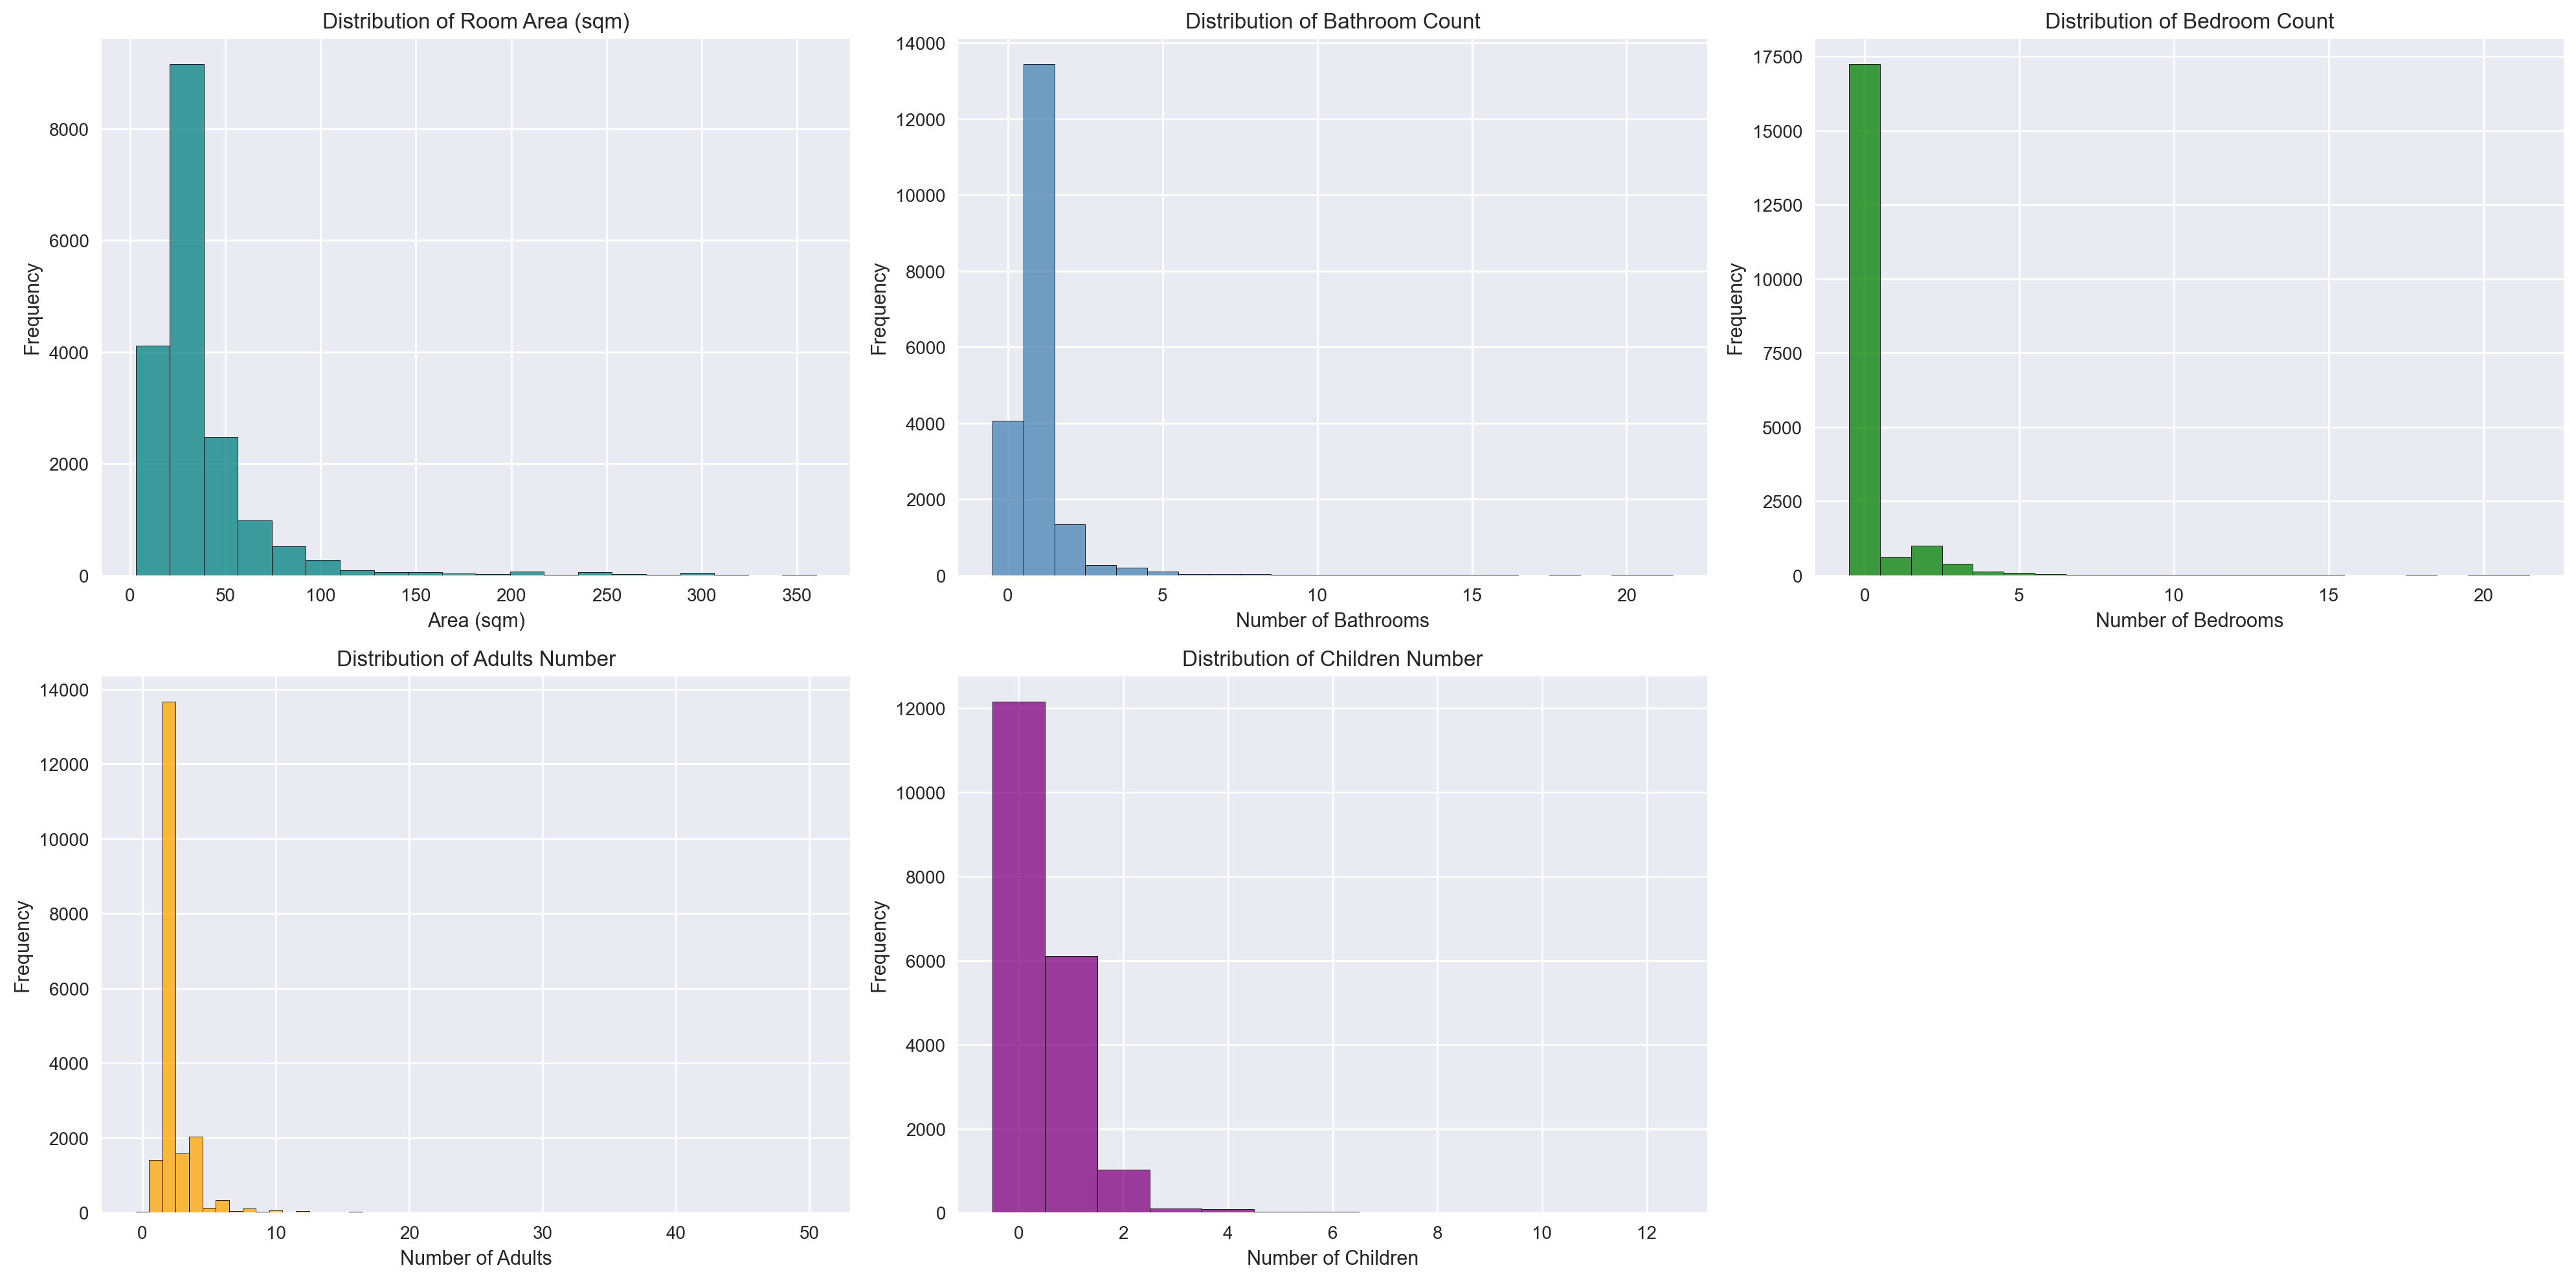

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10), dpi=200)

# Room area (continuous)
if 'sqm' in df.columns:
    sqm_data = df['sqm'].dropna()
    sqm_data = sqm_data[sqm_data <= sqm_data.quantile(0.995)]

    sns.histplot(
        sqm_data,
        bins=20,
        color='teal',
        ax=axes[0, 0]
    )
    axes[0, 0].set_title('Distribution of Room Area (sqm)')
    axes[0, 0].set_xlabel('Area (sqm)')
    axes[0, 0].set_ylabel('Frequency')

# Bathroom count
if 'bathroom_count' in df.columns:
    sns.histplot(
        df['bathroom_count'].dropna(),
        discrete=True,
        color='steelblue',
        ax=axes[0, 1]
    )
    axes[0, 1].set_title('Distribution of Bathroom Count')
    axes[0, 1].set_xlabel('Number of Bathrooms')
    axes[0, 1].set_ylabel('Frequency')

# Bedroom count
if 'bedroom_count' in df.columns:
    sns.histplot(
        df['bedroom_count'].dropna(),
        discrete=True,
        color='green',
        ax=axes[0, 2]
    )
    axes[0, 2].set_title('Distribution of Bedroom Count')
    axes[0, 2].set_xlabel('Number of Bedrooms')
    axes[0, 2].set_ylabel('Frequency')

# Adults number
if 'adults_number' in df.columns:
    sns.histplot(
        df['adults_number'].dropna(),
        discrete=True,
        color='orange',
        ax=axes[1, 0]
    )
    axes[1, 0].set_title('Distribution of Adults Number')
    axes[1, 0].set_xlabel('Number of Adults')
    axes[1, 0].set_ylabel('Frequency')

# Children number
if 'children_number' in df.columns:
    sns.histplot(
        df['children_number'].dropna(),
        discrete=True,
        color='purple',
        ax=axes[1, 1]
    )
    axes[1, 1].set_title('Distribution of Children Number')
    axes[1, 1].set_xlabel('Number of Children')
    axes[1, 1].set_ylabel('Frequency')

# Hide unused subplots
for ax in axes.flatten():
    if not ax.has_data():
        ax.set_visible(False)

plt.tight_layout()
plt.show()


### 1.2 Frequency Analysis for ALL Categorical Columns

Analyze the frequency distribution for every categorical feature.


FREQUENCY ANALYSIS FOR ALL CATEGORICAL COLUMNS

📊 Binary Categorical Columns (0/1 features):
Total: 37 columns


,Column,Count (1/Yes),Percentage (%),Total
0,large_double_bed,7102,36.38%,19520
1,large_bed,4790,24.54%,19520
2,single_bed,4435,22.72%,19520
3,sofa_bed,1045,5.35%,19520
4,double_bed,4692,24.04%,19520
5,small_double_bed,222,1.14%,19520
6,king_size_bed,500,2.56%,19520
7,futon_mattress,206,1.06%,19520
8,bunk_bed,267,1.37%,19520
9,is_private_bathroom,17882,91.61%,19520



📊 Multi-Category Categorical Columns:
Total: 2 columns


VIEWS
Total non-null values: 19,520
Missing values: 0 (0.00%)
Number of unique categories: 7

Top 15 categories:


,Count,Percentage (%)
views,,
no view,5791,30
city,5233,27
nature,3964,20
garden,2266,12
sea,1587,8
lake,351,2
pool,328,2



REGION
Total non-null values: 19,520
Missing values: 0 (0.00%)
Number of unique categories: 42

Top 15 categories:


,Count,Percentage (%)
region,,
Đà Nẵng,3210,16
Thành phố Hồ Chí Minh,2647,14
Hà Nội,2244,12
Ninh Bình,1574,8
Bình Định,1555,8
Thừa Thiên Huế,1539,8
Hải Phòng,1230,6
Cần Thơ,1094,6
Bình Dương,653,3


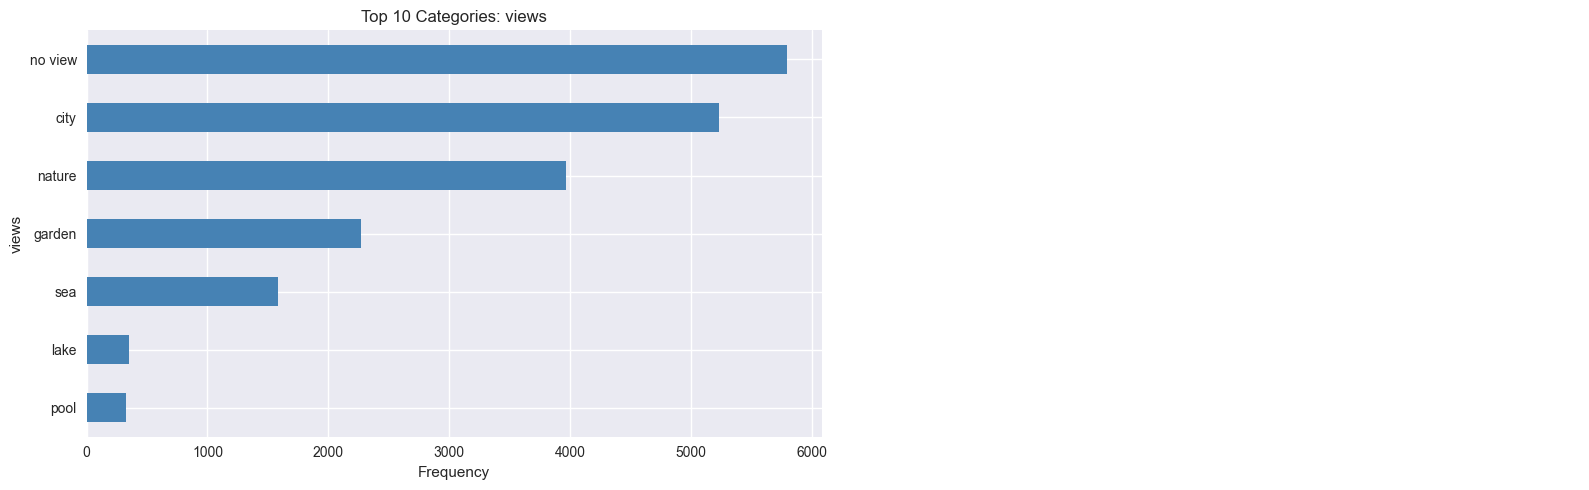

In [10]:
# Frequency Analysis for ALL Categorical Columns
# Exclude hotel_name (not relevant for graphs)
exclude_cat_cols = ['hotel_name']
categorical_cols_clean = [col for col in categorical_cols if col in df.columns and col not in exclude_cat_cols]

# Separate binary (0/1) categorical from multi-category
binary_cats = []
multi_cats = []

for col in categorical_cols_clean:
    if col in df.columns:
        unique_vals = df[col].nunique()
        if unique_vals <= 2:
            binary_cats.append(col)
        else:
            multi_cats.append(col)

print("="*80)
print("FREQUENCY ANALYSIS FOR ALL CATEGORICAL COLUMNS")
print("="*80)

# Analyze binary categorical columns
if binary_cats:
    print("\n📊 Binary Categorical Columns (0/1 features):")
    print(f"Total: {len(binary_cats)} columns")
    
    # Create a summary table for binary columns
    binary_summary = []
    for col in binary_cats:
        value_counts = df[col].value_counts()
        total = len(df[col].dropna())
        if 1 in value_counts.index:
            count_1 = value_counts[1]
            pct_1 = (count_1 / total * 100) if total > 0 else 0
        else:
            count_1 = 0
            pct_1 = 0
        binary_summary.append({
            'Column': col,
            'Count (1/Yes)': count_1,
            'Percentage (%)': f'{pct_1:.2f}%',
            'Total': total
        })
    
    binary_df = pd.DataFrame(binary_summary)
    display(binary_df)

# Analyze multi-category columns (top values)
if multi_cats:
    print("\n📊 Multi-Category Categorical Columns:")
    print(f"Total: {len(multi_cats)} columns\n")
    
    for col in multi_cats:
        print(f"\n{'='*60}")
        print(f"{col.upper()}")
        print(f"{'='*60}")
        value_counts = df[col].value_counts()
        total = len(df[col].dropna())
        missing = df[col].isna().sum()
        
        print(f"Total non-null values: {total:,}")
        print(f"Missing values: {missing:,} ({missing/(total+missing)*100:.2f}%)")
        print(f"Number of unique categories: {df[col].nunique()}")
        print(f"\nTop 15 categories:")
        
        # Show top 15 with percentages
        top_15 = value_counts.head(15)
        freq_df = pd.DataFrame({
            'Count': top_15.values,
            'Percentage (%)': (top_15.values / total * 100).round(2)
        }, index=top_15.index)
        display(freq_df)

# Visualize top categorical columns (excluding binary)
top_cats_to_plot = [col for col in multi_cats if df[col].nunique() <= 20][:6]

if top_cats_to_plot:
    n_plot = len(top_cats_to_plot)
    n_cols = 2
    n_rows = (n_plot + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = np.array(axes).reshape(-1)
    
    for idx, col in enumerate(top_cats_to_plot):
        ax = axes[idx]
        value_counts = df[col].value_counts().head(10)
        value_counts.plot(kind='barh', ax=ax, color='steelblue')
        ax.set_title(f'Top 10 Categories: {col}')
        ax.set_xlabel('Frequency')
        ax.invert_yaxis()
    
    # Hide unused subplots
    for idx in range(n_plot, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()


## 2. Comprehensive Bivariate Analysis

### 2.1 Numerical-Numerical Relationships

Explore relationships between all pairs of numerical variables.


Pairwise Scatter Plot Matrix (Key Numerical Features)
Note: This may take a moment to render...



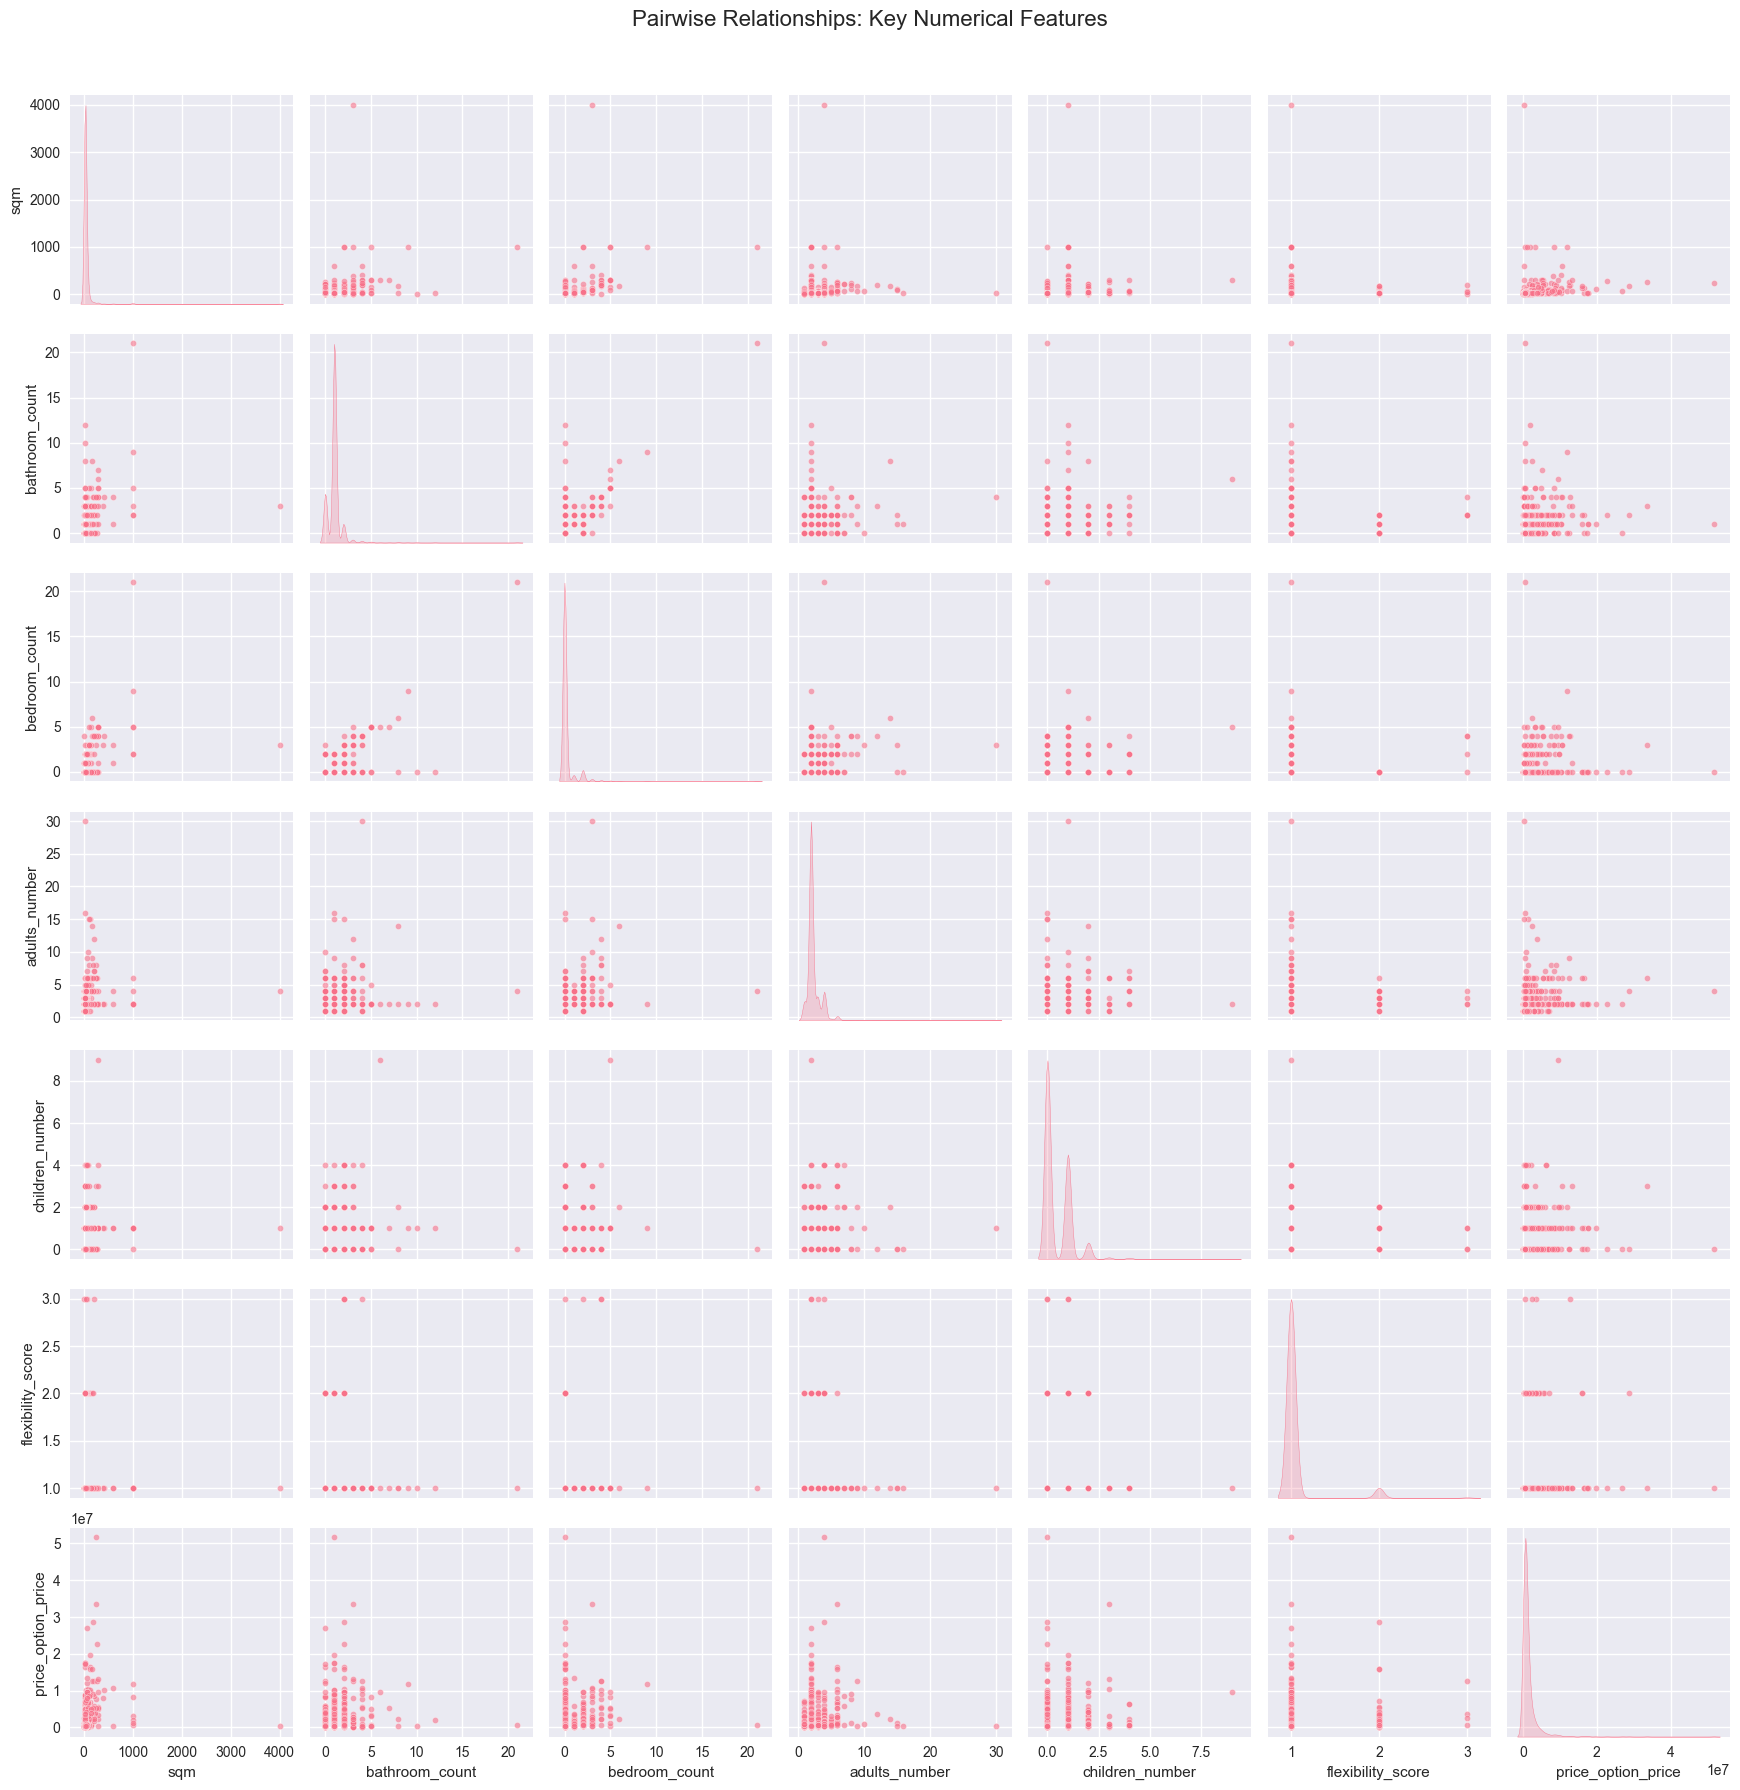

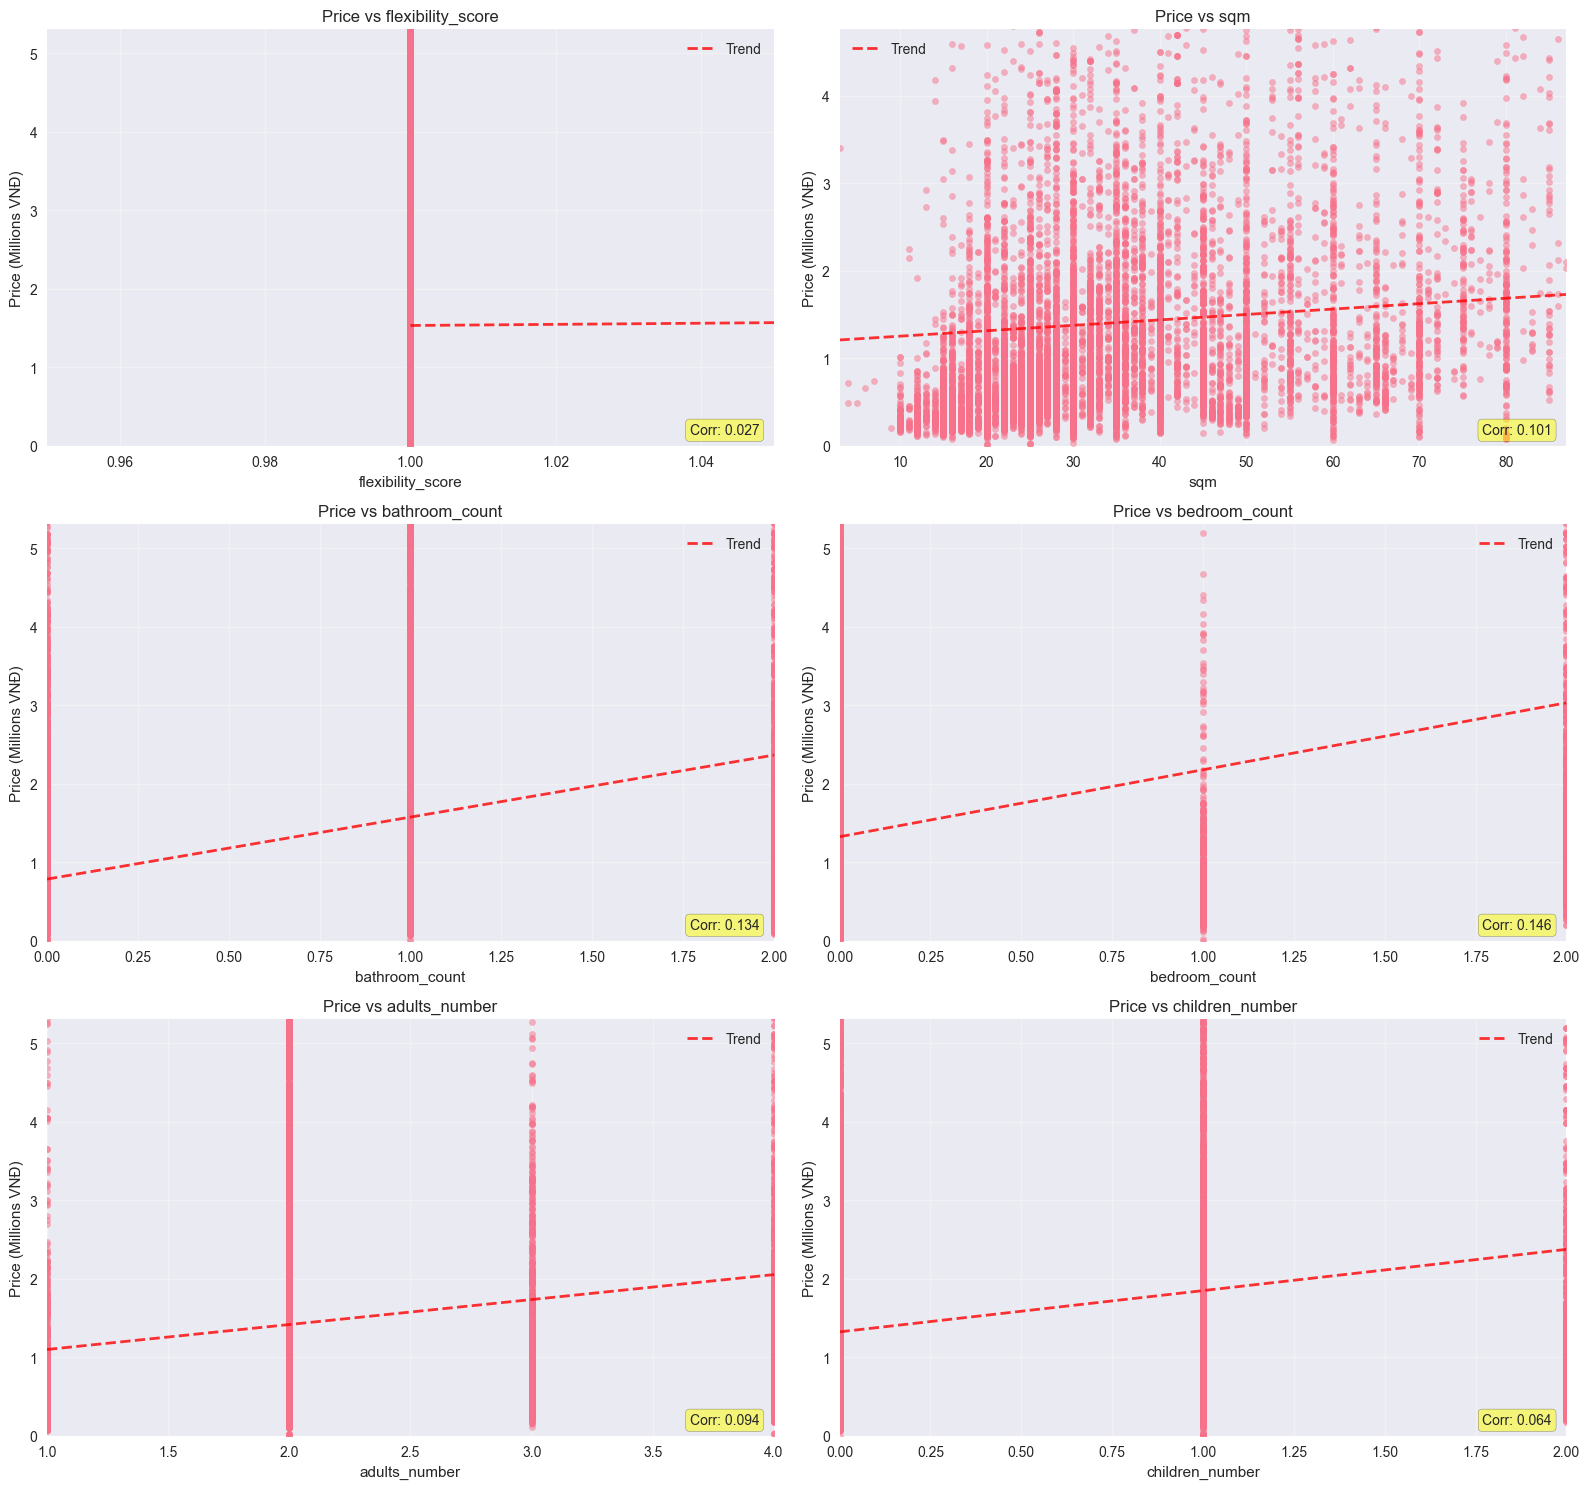


CORRELATION MATRIX: All Numerical Features


,flexibility_score,sqm,bathroom_count,bedroom_count,price_option_price,adults_number,children_number
flexibility_score,1,-0,-0,-0,0,-0,0
sqm,-0,1,0,0,0,0,0
bathroom_count,-0,0,1,1,0,0,0
bedroom_count,-0,0,1,1,0,0,0
price_option_price,0,0,0,0,1,0,0
adults_number,-0,0,0,0,0,1,0
children_number,0,0,0,0,0,0,1



Correlations with Price (price_option_price):


,Correlation with Price
price_option_price,1
bedroom_count,0
bathroom_count,0
sqm,0
adults_number,0
children_number,0
flexibility_score,0


In [11]:
# Comprehensive Numerical-Numerical Relationship Analysis
# Exclude ID columns and có_bữa_sáng (not relevant for graphs)
exclude_cols_analysis = ['hotel_id', 'room_type_id', 'có_bữa_sáng']
numerical_for_analysis = [col for col in numerical_cols if col not in exclude_cols_analysis]

# Scatter plot matrix for key numerical features (excluding price for better visualization)
key_numerical = ['sqm', 'bathroom_count', 'bedroom_count', 'adults_number', 
                 'children_number', 'flexibility_score', 'price_option_price']
key_numerical = [col for col in key_numerical if col in df.columns]

if len(key_numerical) >= 3:
    # Create pairplot for key features
    print("Pairwise Scatter Plot Matrix (Key Numerical Features)")
    print("Note: This may take a moment to render...\n")
    
    # Sample data if too large for pairplot (faster rendering)
    sample_size = min(2000, len(df))
    df_sample = df[key_numerical].dropna().sample(n=sample_size, random_state=42)
    
    sns.pairplot(df_sample, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 20})
    plt.suptitle('Pairwise Relationships: Key Numerical Features', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

# Detailed scatter plots: Each numerical feature vs Price
exclude_cols_scatter = ['hotel_id', 'room_type_id', 'có_bữa_sáng']
non_price_numerical = [col for col in numerical_for_analysis if col != 'price_option_price' and col not in exclude_cols_scatter]

n_features = len(non_price_numerical)
n_cols = 2
n_rows = (n_features + 1) // 2

if n_features > 0:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for idx, col in enumerate(non_price_numerical):
        ax = axes[idx]
        df_clean = df[[col, 'price_option_price']].dropna()
        
        if len(df_clean) > 0:
            # Scatter plot
            ax.scatter(df_clean[col], df_clean['price_option_price'] / 1_000_000, 
                      alpha=0.5, s=20)
            ax.set_xlabel(col)
            ax.set_ylabel('Price (Millions VNĐ)')
            ax.set_title(f'Price vs {col}')
            ax.grid(True, alpha=0.3)
            
            # Add trend line
            z = np.polyfit(df_clean[col], df_clean['price_option_price'], 1)
            p = np.poly1d(z)
            sorted_x = df_clean[col].sort_values()
            ax.plot(sorted_x, p(sorted_x) / 1_000_000, "r--", alpha=0.8, linewidth=2, label='Trend')
            ax.legend()
            
            # Calculate correlation
            corr = df_clean[col].corr(df_clean['price_option_price'])
            ax.text(0.98, 0.02, f'Corr: {corr:.3f}', transform=ax.transAxes,
                   verticalalignment='bottom', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
            
            # Limit axes to 95th percentile for better visualization
            x_max = df_clean[col].quantile(0.95)
            y_max = (df_clean['price_option_price'].quantile(0.95)) / 1_000_000
            ax.set_xlim(df_clean[col].min(), x_max)
            ax.set_ylim(0, y_max)
    
    # Hide unused subplots
    for idx in range(n_features, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Print correlation matrix summary
print("\n" + "="*80)
print("CORRELATION MATRIX: All Numerical Features")
print("="*80)
if len(numerical_for_analysis) > 1:
    corr_matrix = df[numerical_for_analysis].corr()
    display(corr_matrix)
    
    print("\nCorrelations with Price (price_option_price):")
    if 'price_option_price' in corr_matrix.columns:
        price_corr = corr_matrix['price_option_price'].sort_values(ascending=False)
        display(price_corr.to_frame('Correlation with Price'))


### 2.2 Categorical features analysis

Analyze how different amenities affect price.


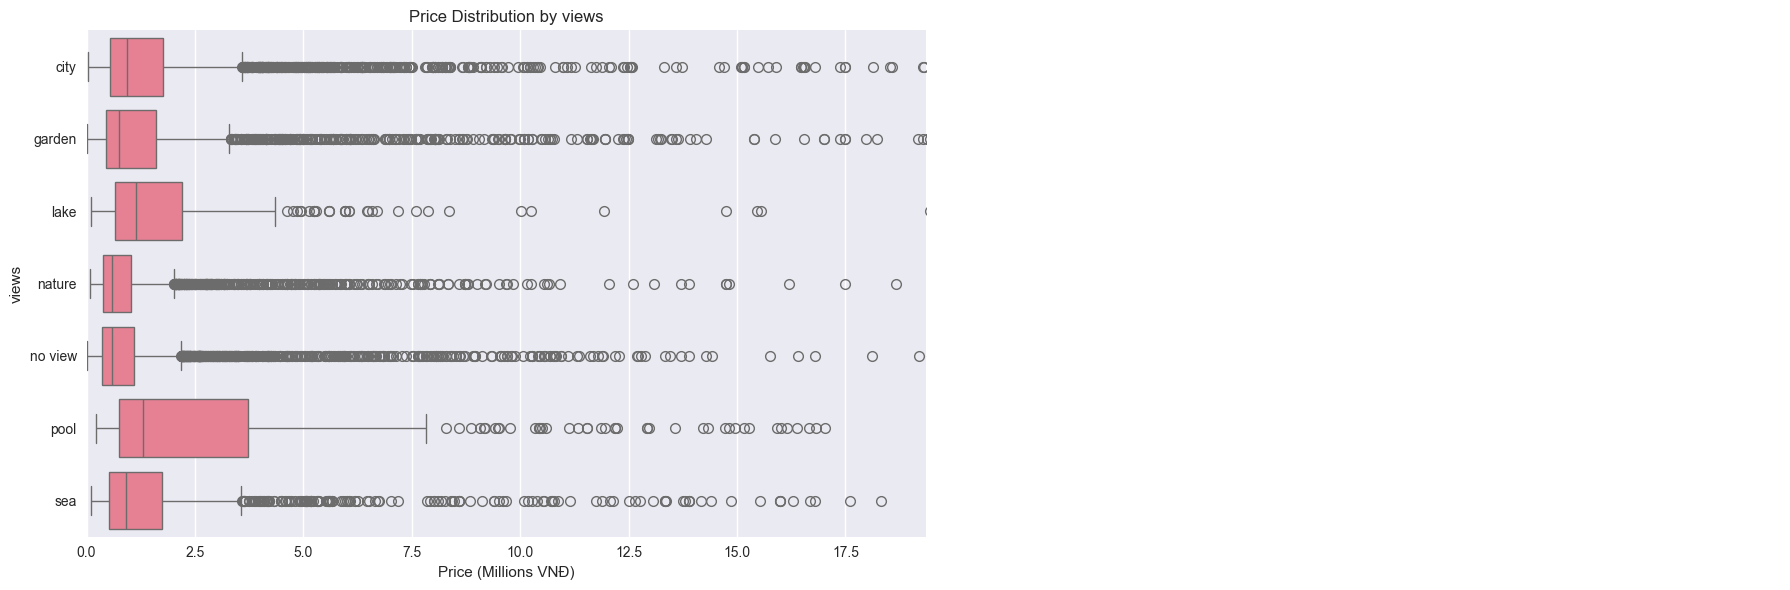

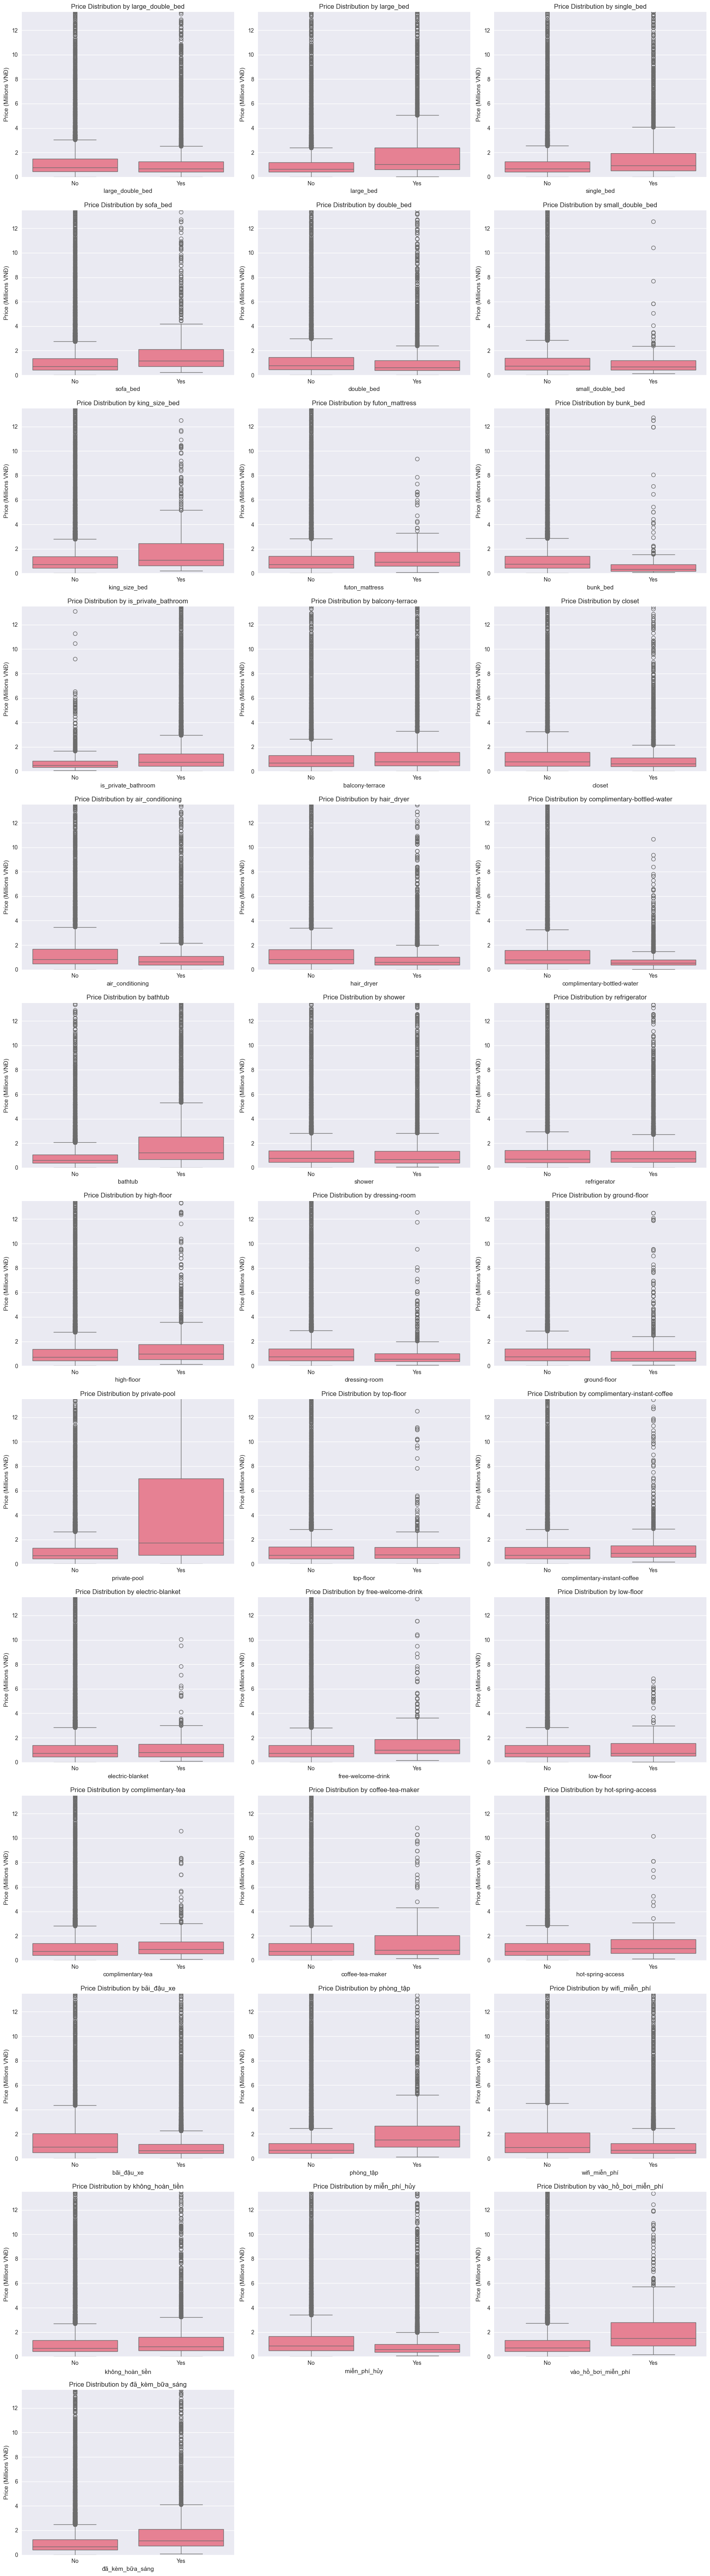


BOXPLOT ANALYSIS COMPLETE (HORIZONTAL VERSION)
Total categorical features analyzed: 38
  - Multi-category features: 1
  - Binary features: 37


In [12]:
# Boxplot Analysis: Price by Categorical Features (HORIZONTAL VERSION)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get categorical columns (excluding some high-cardinality text columns)
exclude_cat_cols = ['hotel_name', 'room_room_type_name', 'region']
categorical_for_plot = [
    col for col in categorical_cols
    if col in df.columns and col not in exclude_cat_cols
]

# Separate binary (0/1) and multi-category features
binary_cats = []
multi_cats = []

for col in categorical_for_plot:
    unique_vals = df[col].nunique()
    if unique_vals <= 2:
        binary_cats.append(col)
    else:
        multi_cats.append(col)

# ============================
# MULTI-CATEGORY: HORIZONTAL BOXPLOTS
# ============================
if len(multi_cats) > 0 and 'price_option_price' in df.columns:
    
    n_plots = len(multi_cats)
    n_cols = 2
    n_rows = (n_plots + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))

    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for idx, cat_col in enumerate(multi_cats):
        ax = axes[idx]

        df_clean = df[[cat_col, 'price_option_price']].dropna()
        if df_clean.empty:
            ax.axis('off')
            continue

        # Select top categories by frequency
        value_counts = df_clean[cat_col].value_counts()

        if cat_col == 'views':
            top_categories = value_counts.index
        else:
            top_k = 10
            top_categories = value_counts.head(top_k).index

        df_top = df_clean[df_clean[cat_col].isin(top_categories)].copy()
        df_top['price_millions'] = df_top['price_option_price'] / 1_000_000

        # Horizontal boxplot
        sns.boxplot(
            data=df_top,
            y=cat_col,
            x='price_millions',
            ax=ax
        )

        ax.set_title(f'Price Distribution by {cat_col}')
        ax.set_xlabel('Price (Millions VNĐ)')
        ax.set_ylabel(cat_col)

        # Limit x-axis to 95th percentile
        x_max = df_top['price_millions'].quantile(0.995)
        ax.set_xlim(0, x_max)

    # Hide unused subplots
    for idx in range(len(multi_cats), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

# ============================
# BINARY CATEGORICAL FEATURES
# ============================
if len(binary_cats) > 0 and 'price_option_price' in df.columns:

    n_plots = len(binary_cats)
    n_cols = 3
    n_rows = (n_plots + 2) // 3

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))

    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for idx, cat_col in enumerate(binary_cats):
        ax = axes[idx]

        df_clean = df[[cat_col, 'price_option_price']].dropna()
        if df_clean.empty:
            ax.axis('off')
            continue

        df_clean = df_clean.copy()
        df_clean['price_millions'] = df_clean['price_option_price'] / 1_000_000

        # Optional: map 0/1 to text
        if set(df_clean[cat_col].unique()).issubset({0, 1}):
            df_clean[cat_col] = df_clean[cat_col].map({0: 'No', 1: 'Yes'})

        sns.boxplot(
            data=df_clean,
            x=cat_col,
            y='price_millions',
            ax=ax
        )

        ax.set_title(f'Price Distribution by {cat_col}')
        ax.set_xlabel(cat_col)
        ax.set_ylabel('Price (Millions VNĐ)')

        y_max = df_clean['price_millions'].quantile(0.99)
        ax.set_ylim(0, y_max)

    # Hide unused subplots
    for idx in range(len(binary_cats), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

# ============================
# SUMMARY
# ============================
print("\n" + "=" * 80)
print("BOXPLOT ANALYSIS COMPLETE (HORIZONTAL VERSION)")
print("=" * 80)
print(f"Total categorical features analyzed: {len(categorical_for_plot)}")
print(f"  - Multi-category features: {len(multi_cats)}")
print(f"  - Binary features: {len(binary_cats)}")


### 2.3 Violin Plot Analysis: Price by Categorical Features

Violin plots show the distribution shape in addition to summary statistics, providing more detailed insights than boxplots.


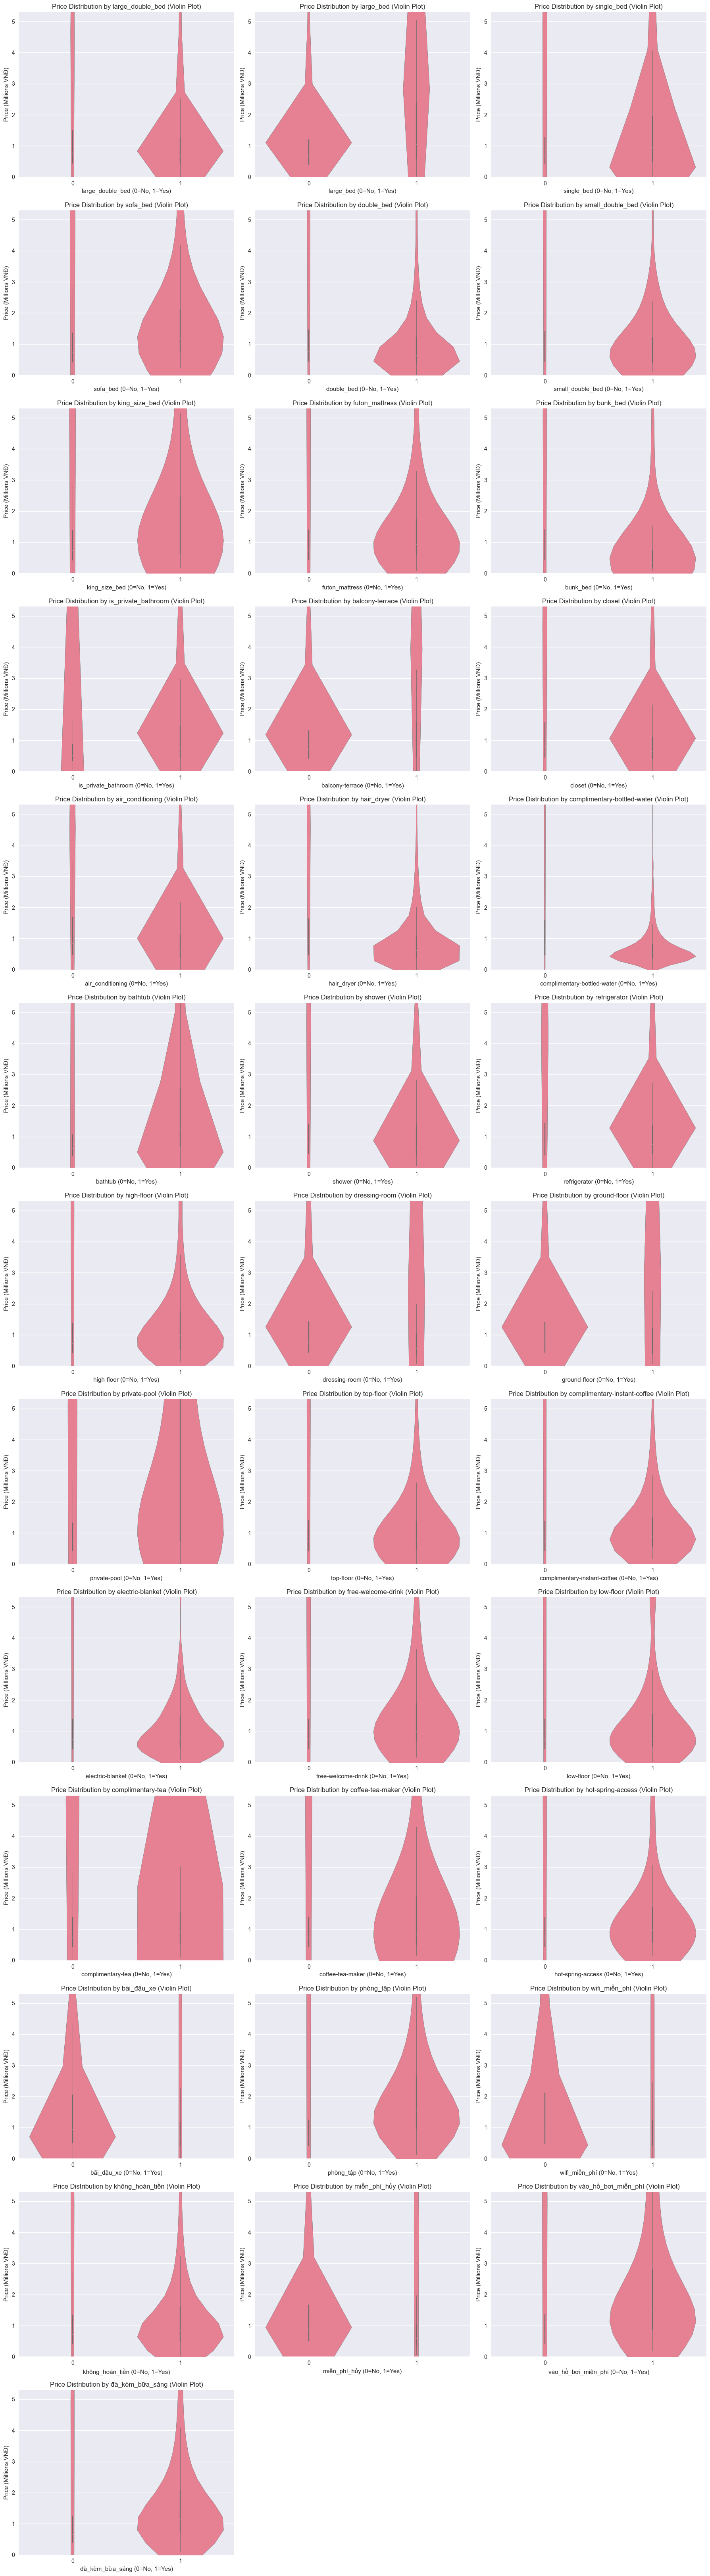


VIOLIN PLOT ANALYSIS COMPLETE
Total categorical features analyzed: 38
  - Multi-category features: 1
  - Binary features: 37


In [13]:
# Violin Plot Analysis: Price by Categorical Features
# Create violin plots for all categorical features (excluding hotel_name, room_room_type_name, and region)
# x-axis: categorical feature values, y-axis: price

# Get categorical columns (excluding hotel_name, room_room_type_name, and region)
exclude_cat_cols = ['hotel_name', 'room_room_type_name', 'region']
categorical_for_plot = [col for col in categorical_cols if col in df.columns and col not in exclude_cat_cols]

# Separate binary (0/1) and multi-category features
binary_cats = []
multi_cats = []

for col in categorical_for_plot:
    if col in df.columns:
        unique_vals = df[col].nunique()
        if unique_vals <= 2:
            binary_cats.append(col)
        else:
            multi_cats.append(col)

# Create violin plots for multi-category features
if len(multi_cats) > 0 and 'price_option_price' in df.columns:
    # Calculate number of subplots needed
    n_plots = len(multi_cats)
    n_cols = 2
    n_rows = (n_plots + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6 * n_rows))
    # Ensure axes is always a 1D list
    if isinstance(axes, np.ndarray):
        axes = axes.flatten().tolist()
    elif not isinstance(axes, list):
        axes = [axes]
    
    for idx, cat_col in enumerate(multi_cats):
        ax = axes[idx]
        df_clean = df[[cat_col, 'price_option_price']].dropna()
        
        if len(df_clean) > 0:
            # Get all categories or top categories based on count
            # For views, show all categories; for others, show top 20
            unique_cats = df_clean[cat_col].value_counts()
            if cat_col == 'views':
                # Show all views categories
                top_categories = unique_cats.index
            else:
                # Show top 20 categories for other features
                top_categories = unique_cats.head(20).index
            df_top = df_clean[df_clean[cat_col].isin(top_categories)]
            
            if len(df_top) > 0:
                df_top['price_millions'] = df_top['price_option_price'] / 1_000_000
                sns.violinplot(data=df_top, x=cat_col, y='price_millions', ax=ax)
                ax.set_title(f'Price Distribution by {cat_col} (Violin Plot)')
                ax.set_xlabel(cat_col)
                ax.set_ylabel('Price (Millions VNĐ)')
                ax.tick_params(axis='x', rotation=45)
                # Limit y-axis to 95th percentile for better visualization
                y_max = df_top['price_millions'].quantile(0.95)
                ax.set_ylim(0, y_max)
    
    # Hide unused subplots
    for idx in range(len(multi_cats), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Create violin plots for binary categorical features (0 vs 1)
if len(binary_cats) > 0 and 'price_option_price' in df.columns:
    # Calculate number of subplots needed
    n_plots = len(binary_cats)
    n_cols = 3
    n_rows = (n_plots + 2) // 3  # Round up division
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    # Ensure axes is always a 1D list
    if isinstance(axes, np.ndarray):
        axes = axes.flatten().tolist()
    elif not isinstance(axes, list):
        axes = [axes]
    
    for idx, cat_col in enumerate(binary_cats):
        ax = axes[idx]
        df_clean = df[[cat_col, 'price_option_price']].dropna()
        
        if len(df_clean) > 0:
            df_clean['price_millions'] = df_clean['price_option_price'] / 1_000_000
            sns.violinplot(data=df_clean, x=cat_col, y='price_millions', ax=ax)
            ax.set_title(f'Price Distribution by {cat_col} (Violin Plot)')
            ax.set_xlabel(f'{cat_col} (0=No, 1=Yes)')
            ax.set_ylabel('Price (Millions VNĐ)')
            # Limit y-axis to 95th percentile for better visualization
            y_max = df_clean['price_millions'].quantile(0.95)
            ax.set_ylim(0, y_max)
    
    # Hide unused subplots
    for idx in range(len(binary_cats), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

print(f"\n{'='*80}")
print("VIOLIN PLOT ANALYSIS COMPLETE")
print(f"{'='*80}")
print(f"Total categorical features analyzed: {len(categorical_for_plot)}")
print(f"  - Multi-category features: {len(multi_cats)}")
print(f"  - Binary features: {len(binary_cats)}")


## 3. Multivariate Analysis

### 3.1 Pattern Discovery Across Multiple Variables

Identify complex patterns and interactions between multiple features.


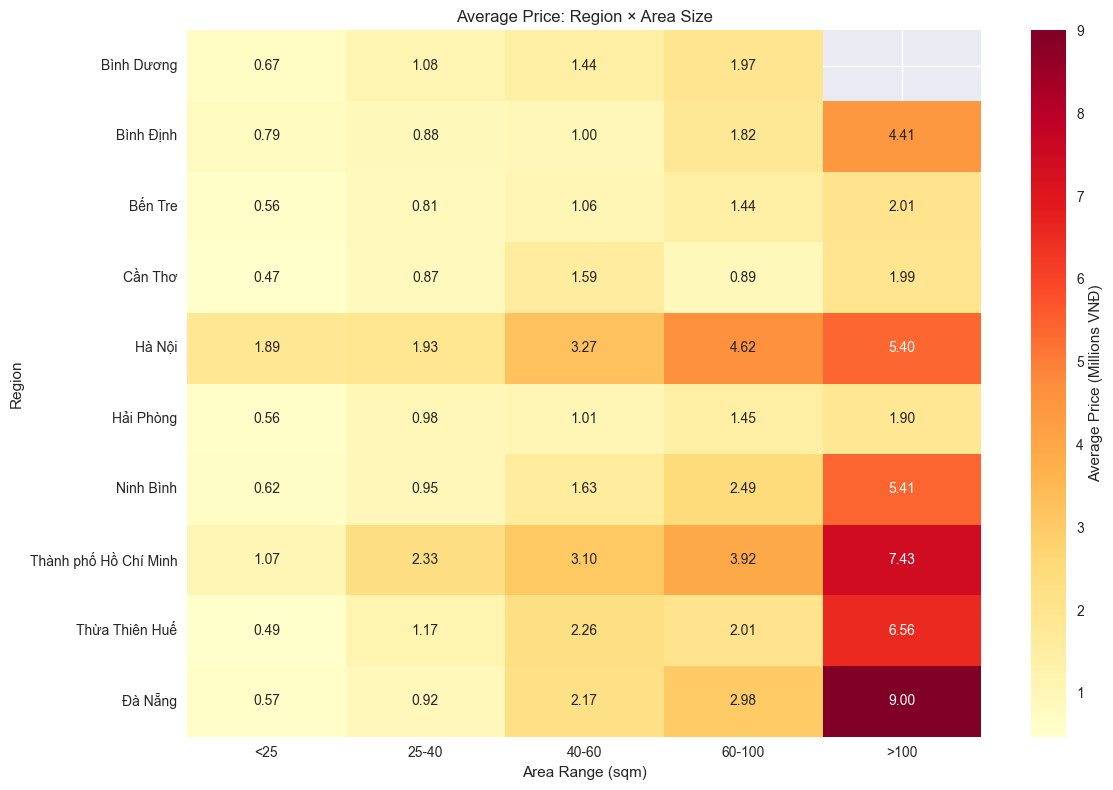

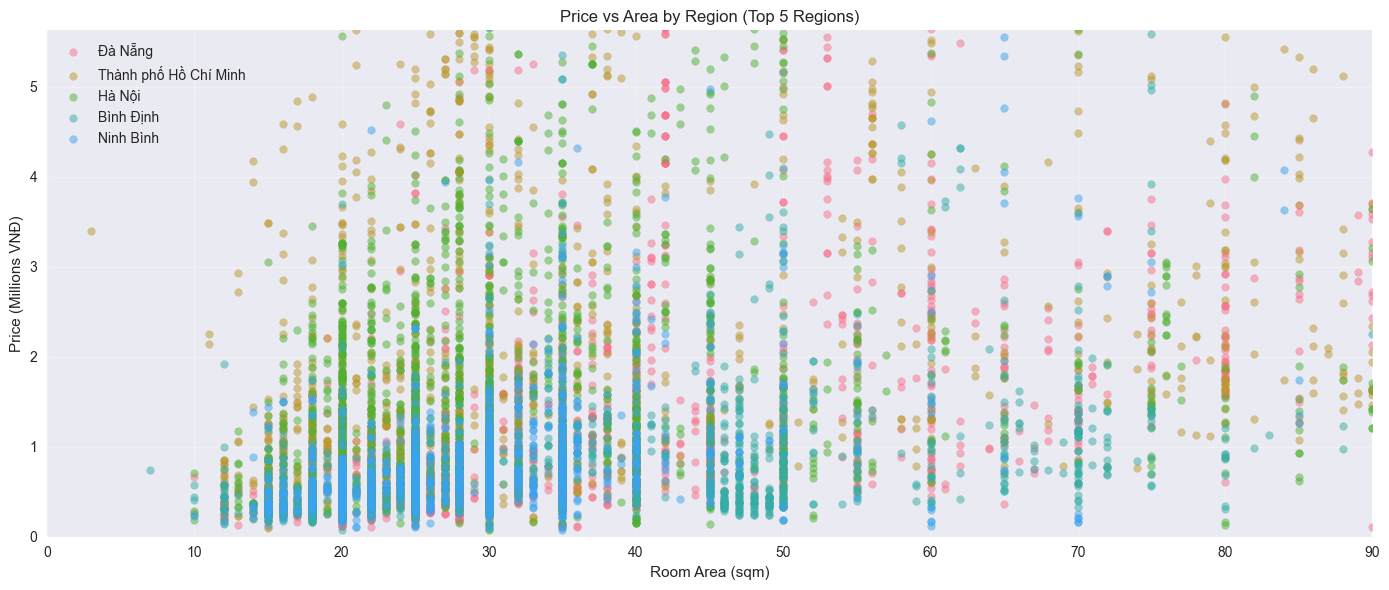

In [14]:
# Multivariate Analysis: Price vs Multiple Features
# Analyze price based on combinations of features

# 1. Price by Region and Room Area
if all(col in df.columns for col in ['region', 'sqm', 'price_option_price']):
    df_clean = df[['region', 'sqm', 'price_option_price']].dropna()
    
    if len(df_clean) > 0:
        # Create area bins
        df_clean['area_bin'] = pd.cut(df_clean['sqm'], 
                                     bins=[0, 25, 40, 60, 100, float('inf')],
                                     labels=['<25', '25-40', '40-60', '60-100', '>100'])
        
        # Calculate average price by region and area bin
        price_by_region_area = df_clean.groupby(['region', 'area_bin'])['price_option_price'].mean().reset_index()
        price_by_region_area['price_millions'] = price_by_region_area['price_option_price'] / 1_000_000
        
        # Pivot for heatmap
        pivot_table = price_by_region_area.pivot(index='region', columns='area_bin', values='price_millions')
        
        # Focus on top regions by room count
        top_regions = df_clean['region'].value_counts().head(10).index
        pivot_top = pivot_table.loc[pivot_table.index.intersection(top_regions)]
        
        if len(pivot_top) > 0:
            plt.figure(figsize=(12, 8))
            sns.heatmap(pivot_top, annot=True, fmt='.2f', cmap='YlOrRd', 
                       cbar_kws={'label': 'Average Price (Millions VNĐ)'})
            plt.title('Average Price: Region × Area Size')
            plt.xlabel('Area Range (sqm)')
            plt.ylabel('Region')
            plt.tight_layout()
            plt.show()

# 2. Price by Room Type and Key Amenities
if all(col in df.columns for col in ['room_room_type_name', 'price_option_price', 'bathtub', 'balcony-terrace']):
    df_clean = df[['room_room_type_name', 'price_option_price', 'bathtub', 'balcony-terrace']].dropna()
    
    if len(df_clean) > 0:
        # Create amenity combination
        df_clean['luxury_amenities'] = df_clean['bathtub'].astype(str) + '-' + df_clean['balcony-terrace'].astype(str)
        df_clean['luxury_amenities'] = df_clean['luxury_amenities'].replace({
            '1-1': 'Both',
            '1-0': 'Bathtub only',
            '0-1': 'Balcony only',
            '0-0': 'Neither'
        })
        
        # Average price by room type and luxury amenities
        top_room_types = df_clean['room_room_type_name'].value_counts().head(8).index
        df_top_types = df_clean[df_clean['room_room_type_name'].isin(top_room_types)]
        
        if len(df_top_types) > 0:
            price_by_type_amenity = df_top_types.groupby(['room_room_type_name', 'luxury_amenities'])['price_option_price'].mean().reset_index()
            price_by_type_amenity['price_millions'] = price_by_type_amenity['price_option_price'] / 1_000_000
            
            plt.figure(figsize=(14, 6))
            pivot_amenity = price_by_type_amenity.pivot(index='room_room_type_name', 
                                                        columns='luxury_amenities', 
                                                        values='price_millions')
            sns.heatmap(pivot_amenity, annot=True, fmt='.2f', cmap='viridis',
                       cbar_kws={'label': 'Average Price (Millions VNĐ)'})
            plt.title('Average Price: Room Type × Luxury Amenities')
            plt.xlabel('Luxury Amenities')
            plt.ylabel('Room Type')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()

# 3. Scatter plot: Price vs Area, colored by Region (top regions)
if all(col in df.columns for col in ['region', 'sqm', 'price_option_price']):
    df_clean = df[['region', 'sqm', 'price_option_price']].dropna()
    top_regions = df_clean['region'].value_counts().head(5).index
    df_top = df_clean[df_clean['region'].isin(top_regions)]
    
    if len(df_top) > 0:
        plt.figure(figsize=(14, 6))
        df_top['price_millions'] = df_top['price_option_price'] / 1_000_000
        
        for region in top_regions:
            region_data = df_top[df_top['region'] == region]
            plt.scatter(region_data['sqm'], region_data['price_millions'], 
                       alpha=0.5, s=30, label=region)
        
        plt.xlabel('Room Area (sqm)')
        plt.ylabel('Price (Millions VNĐ)')
        plt.title('Price vs Area by Region (Top 5 Regions)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Limit axes
        x_max = df_top['sqm'].quantile(0.95)
        y_max = df_top['price_millions'].quantile(0.95)
        plt.xlim(0, x_max)
        plt.ylim(0, y_max)
        plt.tight_layout()
        plt.show()


### 3.2 Segmentation and Grouping Insights

Identify meaningful segments based on multiple features.


PRICE SEGMENTATION ANALYSIS

Segment Distribution:


,Count
price_segment,
Economy (Q2),4879
Budget (Q1),4874
Premium (Q4),4873
Mid-range (Q3),4865
Missing,29



Average Characteristics by Price Segment:


,Count,Avg Price (Millions),Avg sqm,Avg Bathrooms,Avg Bedrooms,Avg Adults
price_segment,,,,,,
Budget (Q1),4874,0,28,1,0,2
Economy (Q2),4879,1,31,1,0,2
Mid-range (Q3),4865,1,37,1,0,2
Missing,0,NaN,50,0,0,0
Premium (Q4),4873,4,70,1,1,3



Top Regions by Segment:

Budget (Q1):
  Đà Nẵng: 758 (15.6%)
  Cần Thơ: 570 (11.7%)
  Bình Định: 539 (11.1%)
  Thừa Thiên Huế: 532 (10.9%)
  Ninh Bình: 329 (6.8%)

Economy (Q2):
  Đà Nẵng: 739 (15.1%)
  Ninh Bình: 589 (12.1%)
  Thành phố Hồ Chí Minh: 496 (10.2%)
  Thừa Thiên Huế: 445 (9.1%)
  Hà Nội: 430 (8.8%)

Mid-range (Q3):
  Thành phố Hồ Chí Minh: 822 (16.9%)
  Đà Nẵng: 684 (14.1%)
  Hà Nội: 574 (11.8%)
  Ninh Bình: 451 (9.3%)
  Bình Định: 419 (8.6%)

Premium (Q4):
  Thành phố Hồ Chí Minh: 1098 (22.5%)
  Đà Nẵng: 1029 (21.1%)
  Hà Nội: 1002 (20.6%)
  Thừa Thiên Huế: 280 (5.7%)
  Ninh Bình: 205 (4.2%)

Amenity Prevalence by Price Segment:


,bathtub,balcony-terrace,private-pool,wifi_miễn_phí,vào_hồ_bơi_miễn_phí,phòng_tập
Budget (Q1),13,34,2,78,1,2
Economy (Q2),20,37,3,78,1,4
Mid-range (Q3),31,38,4,76,4,13
Premium (Q4),53,43,12,63,6,23


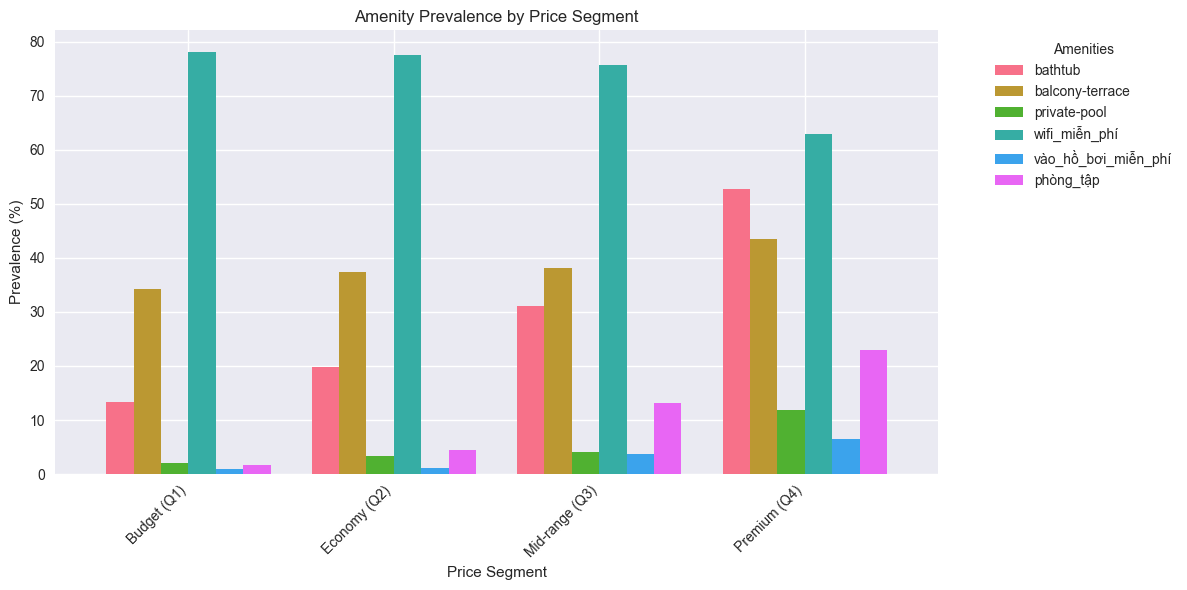

In [15]:
# Segmentation Analysis: Create price segments and analyze characteristics

if 'price_option_price' in df.columns:
    # Create price segments
    price_quartiles = df['price_option_price'].quantile([0.25, 0.5, 0.75])
    df_segmented = df.copy()
    
    def assign_price_segment(price):
        if pd.isna(price):
            return 'Missing'
        elif price <= price_quartiles[0.25]:
            return 'Budget (Q1)'
        elif price <= price_quartiles[0.5]:
            return 'Economy (Q2)'
        elif price <= price_quartiles[0.75]:
            return 'Mid-range (Q3)'
        else:
            return 'Premium (Q4)'
    
    df_segmented['price_segment'] = df_segmented['price_option_price'].apply(assign_price_segment)
    
    print("="*80)
    print("PRICE SEGMENTATION ANALYSIS")
    print("="*80)
    
    # Segment distribution
    segment_counts = df_segmented['price_segment'].value_counts()
    print("\nSegment Distribution:")
    display(segment_counts.to_frame('Count'))
    
    # Characteristics by segment
    print("\nAverage Characteristics by Price Segment:")
    segment_char = df_segmented.groupby('price_segment').agg({
        'price_option_price': ['count', 'mean', 'median'],
        'sqm': 'mean',
        'bathroom_count': 'mean',
        'bedroom_count': 'mean',
        'adults_number': 'mean'
    }).round(2)
    
    segment_char.columns = ['Count', 'Avg Price', 'Median Price', 'Avg sqm', 
                           'Avg Bathrooms', 'Avg Bedrooms', 'Avg Adults']
    segment_char['Avg Price (Millions)'] = segment_char['Avg Price'] / 1_000_000
    display(segment_char[['Count', 'Avg Price (Millions)', 'Avg sqm', 
                         'Avg Bathrooms', 'Avg Bedrooms', 'Avg Adults']])
    
    # Region distribution by segment
    if 'region' in df.columns:
        print("\nTop Regions by Segment:")
        for segment in ['Budget (Q1)', 'Economy (Q2)', 'Mid-range (Q3)', 'Premium (Q4)']:
            segment_data = df_segmented[df_segmented['price_segment'] == segment]
            if len(segment_data) > 0:
                top_regions = segment_data['region'].value_counts().head(5)
                print(f"\n{segment}:")
                for region, count in top_regions.items():
                    pct = (count / len(segment_data)) * 100
                    print(f"  {region}: {count} ({pct:.1f}%)")
    
    # Amenity prevalence by segment
    amenity_cols_seg = ['bathtub', 'balcony-terrace', 'private-pool', 'jacuzzi-bathtub',
                       'wifi_miễn_phí', 'vào_hồ_bơi_miễn_phí', 'phòng_tập']
    amenity_cols_seg = [col for col in amenity_cols_seg if col in df.columns]
    
    if amenity_cols_seg:
        print("\nAmenity Prevalence by Price Segment:")
        amenity_by_segment = {}
        
        for segment in ['Budget (Q1)', 'Economy (Q2)', 'Mid-range (Q3)', 'Premium (Q4)']:
            segment_data = df_segmented[df_segmented['price_segment'] == segment]
            if len(segment_data) > 0:
                amenity_pct = {}
                for amenity in amenity_cols_seg:
                    if amenity in segment_data.columns:
                        # Convert to numeric if needed
                        amenity_values = pd.to_numeric(segment_data[amenity], errors='coerce')
                        pct = (amenity_values == 1).sum() / len(segment_data) * 100
                        amenity_pct[amenity] = pct
                amenity_by_segment[segment] = amenity_pct
        
        amenity_seg_df = pd.DataFrame(amenity_by_segment).T
        display(amenity_seg_df.round(1))
        
        # Visualization
        if len(amenity_seg_df) > 0:
            plt.figure(figsize=(12, 6))
            amenity_seg_df.plot(kind='bar', ax=plt.gca(), width=0.8)
            plt.title('Amenity Prevalence by Price Segment')
            plt.xlabel('Price Segment')
            plt.ylabel('Prevalence (%)')
            plt.legend(title='Amenities', bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()

# Hotel-level segmentation removed - hotel_name not relevant for graphs
# Note: Hotel-level analysis can be done separately if needed, but excluded from graph visualizations


## 4. Comprehensive Business Insights & Recommendations

### 4.1 Key Findings Summary


**Dataset Overview:**
- Total Records: 16,479 hotel room listings (after cleaning)
- Total Features: 40 columns
- Target Variable: `price_option_price` (Room price in VNĐ)
- Data Quality: Cleaned dataset with outlier treatment (from Step 2)

**Key Statistical Insights:**

1. **Price Distribution:**
   - Highly right-skewed distribution indicating a price-sensitive market
   - Median price (674,769 VNĐ) significantly lower than mean (1,376,844 VNĐ)
   - Large standard deviation (5.9M VNĐ) indicates high price variability
   - Clear segmentation: Budget, Economy, Mid-range, and Premium segments

2. **Geographic Patterns:**
   - Strong regional price variation (Vũng Tàu highest, some regions much lower)
   - Tourism destinations (Đà Nẵng, Ninh Bình) show premium pricing
   - Major cities (Hà Nội) have diverse price ranges across segments

3. **Room Characteristics Impact:**
   - Area (sqm) shows weak positive correlation (0.066) with price
   - Larger rooms (>60 sqm) show high price variability
   - Room type and amenities have stronger impact than area alone

4. **Amenity Effects:**
   - Luxury amenities (bathtub, balcony, private pool) associated with premium pricing
   - Basic amenities (WiFi, parking) have moderate impact
   - Some amenities (refrigerator) show negative correlation (may indicate budget segments)

5. **Multivariate Patterns:**
   - Region × Area combinations reveal distinct pricing strategies
   - Room type × Amenity combinations drive significant price differences
   - Hotel-level analysis shows consistent pricing within establishments


### 4.2 Impact of Outlier Treatment

The analysis was performed on cleaned, outlier-treated data, which ensures:
- More reliable statistical measures (mean, median, correlation)
- Better visualization quality without extreme outliers distorting scales
- Accurate identification of true market segments and patterns
- Reduced impact of data errors or exceptional cases

**What was preserved:**
- All valid market segments including premium/luxury offerings
- Natural price distribution patterns
- Meaningful variations across regions and room types

**Benefits observed:**
- Clearer visualization of relationships between variables
- More interpretable correlation coefficients
- Better segmentation that reflects actual market structure


### 4.3 Actionable Recommendations


In [ ]:
print("="*80)
print("ACTIONABLE RECOMMENDATIONS")
print("="*80)

print("""
1. PRICING STRATEGY:
   - Implement segment-based pricing: Budget, Economy, Mid-range, Premium
   - Regional pricing adjustment: Higher premiums in tourist destinations
   - Room type differentiation: Premium types justify higher prices when combined with amenities

2. FEATURE OPTIMIZATION:
   - Focus on luxury amenities (bathtub, balcony) for premium segments
   - Basic amenities (WiFi, parking) are expected across all segments
   - Area alone is weak predictor - emphasize amenities and room type

3. MARKET POSITIONING:
   - Identify gap markets: Regions with limited premium options
   - Hotel branding: Consistent pricing within hotels strengthens brand positioning
   - Competitive analysis: Compare pricing against regional averages

4. REVENUE OPTIMIZATION:
   - Upsell opportunities: Promote luxury amenities to mid-range customers
   - Package deals: Bundle popular amenities (WiFi + parking + breakfast)
   - Dynamic pricing: Adjust based on room type × region × amenities combinations

5. DATA-DRIVEN DECISIONS:
   - Monitor price elasticity by segment
   - Track amenity ROI (price premium vs. amenity cost)
   - Analyze seasonal patterns (if time data available)
""")


ACTIONABLE RECOMMENDATIONS

1. PRICING STRATEGY:
   - Implement segment-based pricing: Budget, Economy, Mid-range, Premium
   - Regional pricing adjustment: Higher premiums in tourist destinations
   - Room type differentiation: Premium types justify higher prices when combined with amenities

2. FEATURE OPTIMIZATION:
   - Focus on luxury amenities (bathtub, balcony) for premium segments
   - Basic amenities (WiFi, parking) are expected across all segments
   - Area alone is weak predictor - emphasize amenities and room type

3. MARKET POSITIONING:
   - Identify gap markets: Regions with limited premium options
   - Hotel branding: Consistent pricing within hotels strengthens brand positioning
   - Competitive analysis: Compare pricing against regional averages

4. REVENUE OPTIMIZATION:
   - Upsell opportunities: Promote luxury amenities to mid-range customers
   - Package deals: Bundle popular amenities (WiFi + parking + breakfast)
   - Dynamic pricing: Adjust based on room type × reg

### 4.4 Suggested Next Steps for Predictive Analysis


In [ ]:
print("="*80)
print("NEXT STEPS FOR PREDICTIVE ANALYSIS")
print("="*80)

print("""
1. FEATURE ENGINEERING:
   - Create composite features:
     * Price per sqm (price / sqm)
     * Amenity count (sum of binary amenities)
     * Luxury score (weighted sum of premium amenities)
     * Room capacity score (adults_number + children_number)
   - Encode categorical variables:
     * One-hot encoding for room types, regions
     * Target encoding for high-cardinality categories (hotel_name)
   - Handle missing values:
     * Impute missing sqm based on room type and region
     * Impute missing views based on region and hotel type

2. MODELING APPROACHES:
   - Regression Models:
     * Linear Regression (baseline)
     * Ridge/Lasso Regression (handle multicollinearity)
     * Random Forest (capture non-linear relationships)
     * Gradient Boosting (XGBoost, LightGBM) - recommended
   - Consider price segmentation:
     * Separate models for each price segment
     * Or use multi-output regression
   
3. EVALUATION METRICS:
   - Primary: RMSE, MAE (on original scale)
   - Secondary: R², MAPE (Mean Absolute Percentage Error)
   - Business metric: Revenue prediction accuracy

4. FEATURE SELECTION:
   - Use correlation analysis (already done)
   - Recursive Feature Elimination
   - Feature importance from tree-based models
   - Remove highly correlated features (multicollinearity)

5. MODEL VALIDATION:
   - Train/Test split (80/20 or 70/30)
   - Cross-validation (k-fold, stratified by region/price segment)
   - Temporal validation (if time data available)
   - Out-of-sample testing on new hotels/regions

6. ADVANCED ANALYSIS:
   - Price elasticity modeling
   - Demand forecasting
   - Competitive pricing analysis
   - Recommendation systems for room selection
   - A/B testing framework for pricing strategies
""")

print("\n" + "="*80)
print("EDA COMPLETE - Ready for Modeling Phase")
print("="*80)


NEXT STEPS FOR PREDICTIVE ANALYSIS

1. FEATURE ENGINEERING:
   - Create composite features:
     * Price per sqm (price / sqm)
     * Amenity count (sum of binary amenities)
     * Luxury score (weighted sum of premium amenities)
     * Room capacity score (adults_number + children_number)
   - Encode categorical variables:
     * One-hot encoding for room types, regions
     * Target encoding for high-cardinality categories (hotel_name)
   - Handle missing values:
     * Impute missing sqm based on room type and region
     * Impute missing views based on region and hotel type

2. MODELING APPROACHES:
   - Regression Models:
     * Linear Regression (baseline)
     * Ridge/Lasso Regression (handle multicollinearity)
     * Random Forest (capture non-linear relationships)
     * Gradient Boosting (XGBoost, LightGBM) - recommended
   - Consider price segmentation:
     * Separate models for each price segment
     * Or use multi-output regression

3. EVALUATION METRICS:
   - Primary: RM

## 4. Overview Summary

Summary of key findings and insights from the exploratory data analysis.


### Dataset Overview

**Dataset Information:**
- **Total Records**: 16,509 hotel room listings
- **Total Features**: 40 columns
- **Target Variable**: `price_option_price` (Room price in VNĐ)
- **Missing Values in Target**: 30 records (0.18%)

### Key Insights

**1. Target variable analysis (Price):**
- Biểu đồ histogram bên trái cho thấy dữ liệu bị lệch phải (right-skewed), phần lớn các cột tập trung bên trái. Biểu đồ cho thất đa số các phòng có giá thấp, số lượng phòng có giá cao ít hơn rất nhiều. Đỉnh nằm trong khoảng 300k-500k.
- Boxplot cho thấy hộp chữ nhật đại diện 50% dữ liệu nằm trong khoảng 400k-1.25 triệu, nghĩa là một nửa thị trường nằm trong giá này, median = 700k. Giải màu đen dày đặc thể hiện có một số lượng lớn outliers có giá rất cao (>2.5 triệu) so với mặt bằng chung. Dù không là đa số nhưng mật độ dày đặc cho thấy phân khúc này có nhiều lựa chọn và cần được xem xét, không thể drop.


**2. Price analysis by region:**
- Bar chart bên phải cho thấy sự chênh lệch rõ ràng về giá trung bình ở từng địa phương. Ta có thể chia các địa phương thành từng nhóm, ví dụ cao vượt trội là Vũng Tàu, nhóm tiếp theo là Hà Nội, Bắc Ninh, Đà Nẵng, Ninh Bình; ta có thể thấy rõ đây là các thành phố lớn hoặc các thành phố du lịch nên chúng thuộc cùng 1 nhóm là hợp lí.
- Boxplot bên trái cho thấy sự thống nhất của các thủ phủ du lịch về giá trần. Các thành phố du lịch lớn xuất hiện dày đặc outliers. Tại các khu vực này, phân khúc hạng sang phát triển mạnh. Dù giá trung bình khoảng 1-2 triệu, nhưng luôn sẵn các lựa chọn cao cấp với mức giá tách biệt hoàn toàn so với mặt bằng chung. Vũng Tàu có mặt bằng giá chung cao nhất, tức không chỉ có resort đắt tiền, ngày cả giá khách sạn bình/nhà nghỉ bình dân tại Vũng Tàu cũng có giá sàn cao hơn các nơi khác. Đi du lịch Vũng Tàu trung bình sẽ tốn tiền phòng hơn so với nơi khác xét ở phân khúc phổ thông.
- Các tỉnh lẻ như Bắc Kạn, Hậu Giang, Cà Mau, Bình Phước hộp rất ngắn, rất ít hoặc không có outliers. Tức thị trương ở đây hầu hết bình dân với mức giá sàn như nhau (khoảng 300k-500k), khó có thể tìm thấy khách sạn dịch vụ cao cấp ở đây.
- Rủi ro khi dùng giá trung bình với sự xuất hiện quá nhiều outliers 


**3. Price vs Room Characteristics:**
- Scatter plot bên trái có dasked line đỏ hướng lên trên từ trái sang phải. Điều này khảng định 1 nhận định cơ bản: diện tích càng lớn thì giá phòng càng cao.
- Scatterplot có đám mây điểm dày ở góc dưới bên trái - diện tích nhỏ, giá thấp. Tuy nhiên, có rất nhiều điểm tản ra theo chiều dọc tại cùng các mốc diện tích.
- Trong boxplot bên phải, các box <25 và 25-40 có chiều cao thấp, chứng tỏ giá của phòng có diện tích nhỏ hầu hết rẻ và không giao động nhiều, ổn định.
- Các box >40 có chiều cao lớn, chứng tỏ phòng lớn có mức độ giao động lớn.
- Các vòng tròn phía trên điểm râu (whisker) biểu thị nhiều outliers. Đặc biệt các phòng >60 có outliers chạm mốc 15-30 triệu. Điều này nói lên rằng diện tích là 1 yếu tố quyết định giá, nhưng các features khác mới là yếu tố quyết định giá trần.
- Tóm lại có sự tương quan giữa dieenjtichs và giá, nhưng không chặt chẽ tuyệt đối. Các điểm dữ liệu phân tán nhiều, nghĩa là chỉ dựa vào diện tích thì không dự đoán chính xác được. Về phân khúc, <40 có giá ổn định, >60 phân hóa mạnh, giá phụ thuộc nhiều vào cả tiện nghi chứ không chỉ kích thước.


**4. Correlation analysis:**
- Các ô đỏ đậm ở trung tâm cho thấy các mối quan hệ logic rõ ràng. Số phòng ngủ và phòng tắm (0.693) là tương quan mạnh nhất, nhà càng nhiều phòng ngủ thì có càng nhiều phòng tắm, điều này hoàn toàn hợp lý về mặt thiết kế. Số phòng ngủ và số người lớn (0.502) tương quan khá mạnh, càng nhiều phòng ngủ thì sức chứa càng tăng. Tương tự với các cột và dòng khác.
- Giá phòng hầu như KHÔNG phụ thuộc vào kích thước hay tiện nghi vật lý. Tương quan giá với diện tích (sqm) là 0.066, với số phòng ngủ là 0.092,... Điều này thể hiện một ăn phòng rộng hơn hay nhiều phòng hơn và cho nhiều người hơn không đồng nghĩa với việc giá của nó sẽ cao hơn đáng kể. Có thể giá cả bị chi phối mạnh hơn bởi các yếu tố nội thất (amenities) không nằm trong biểu đồ này.
- flexibility_score toàn xám nhạt với chỉ số gần bằng 0 và âm, cho thấy yếu tố này không liên quan đến giá tiền và các đặc trưng vật lý.
- Tóm lại, chỉ các biến số vật lý là không đủ để dự đoán giá chính xác, vì tương quan thấp. Cần nghiên cứu các đặc trưng liên quan tới nội thất.


**5. Amenities impact analysis:**
- Tiện nghi private_pool tạo sự khác biệt khổng lồ về giá, giúp giá phòng tăng thêm trung bình 3.000.000 VND. Đây là dấu hiệu nhận biết rõ ràng nhất của phân khúc hạng sang.
- Nhóm các tiện ích cao cấp cũng kéo giá phòng lên mạnh từ 1-1.5 triệu: phòng_tập, vào_hồ_bơi_miễn_phí, large_bed, đã_kèm_bữa_sáng.
- Các tiện nghi cơ bản như refrigerator, shower, air_conditioning, closet lại nằm ở phía giá trị âm (500k-700k so với mức trung bình). Điều này không có nghĩa là các tiện nghi cơ bản khiến giá phòng bị giảm. Do phân khúc bình dân thường liệt kê các món cơ bản này để thu hút khách tìm phòng giá rẻ, sự xuất hiện của các từ khóa này thường gắn liền với các phòng giá thấp. Phân khúc cao cấp thường mặc định đã có những thứ này nên họ không liệt kê nữa, hoặc thường dùng những từ mỹ miều hơn (ví dụ bathtub thay cho shower, minibar thay cho refrigerator).
- Tóm lại, các từ khóa liên quan đến tiện nghi cao cấp ảnh hưởng lớn tới sự tăng giá phòng. Nếu danh sách tiện nghi liệt kê nhiều thứ cơ bản, đó thường là dấu hiệu của phân khúc bình dân học vụ.


### PART 2: Comprehensive exploratory data analysis

**1. Comprehensive univariate analysis**
- Tất cả 5 biểu đồ đều bị lệch phải (right-skewed) rất nặng. Điều này nghĩa là các giá trị nhỏ chiếm đại đa số, còn các giá trị lớn rất hiếm.
- Diện tích: phần lớn các phòng có diện tích tập trung khoảng 20-40 mét vuông. Đây là diện tích tiêu chuẩn của một phòng khách sạn thường thấy. Rất ít phòng có diện tích > 100 mét vuông.
- Số phòng ngủ: cột 0 và 1 cao nhất. 0 phòng ngủ thường ám chỉ dạng phòng giường ngủ chung không gian phòng khách/bếp. Căn hộ nhiều phòng ngủ (2-3 phòng) chiếm tỉ lệ rất nhỏ.
- Phòng tắm: đại đa số chỉ có 1 phòng tắm. Điều này phù hợp với cấu trúc diện tích nhỏ và 1 phòng ngủ ở trên.
- Số người lớn: đỉnh biểu đồ nằm chót vót ở số 2. Điều này khẳng định loại phòng phổ biến nhất được thiết kế cho 2 người lớn (các cặp đôi hoặc 2 bạn đi du lịch). Số lượng phòng dành cho nhóm lớn >3 người là rất ít.
- Số trẻ em: đỉnh nằm ở số 0. Phần lớn chính sách phòng mặc định không gồm trẻ em, đối tường chủ yếu là người lớn. Chỉ hơn một nửa là thiết kế cho gia đình có 1-2 trẻ nhỏ. Thực ra con số 0 này không phản ánh chính xác thực tế nhu cầu du lịch, các gia đình thường đi cùng con nhỏ. Đây là do nghiệp vụ đặt phòng hơn là do đặc điểm nhân khẩu học: các nền tảng đặt phòng thường được định nghĩa dựa trên số lượng người lớn, trẻ em thường được coi là đối tường đi kèm và dùng chung giường nên cơ sở dữ liệu trường children thường bỏ trống hoặc mặc định là 0 vì nó không ảnh hưởng trực tiếp đến giá cơ bản; chủ khách sạn thường lười điền chi tiết mục trẻ em vì chính sách trẻ em thường phức tạp hơn (< 6 tuổi miễn phí, 6-12 tuổi phụ thu...) nên họ thường để mặc định là 0 và trẻ em thường được free. Vậy nên ta đừng quá tin cậy vào cột số lượng trẻ em, nó có thể không mang nhiều ý nghĩa dự đoán giá, tương tự như biểu đồ heatmap, tương giá giá nhà với số người lớn > tương quan giá nhà với số trẻ em.
- Tóm lại, dữ liệu đại diện chủ yếu cho thị trường khách sạn bình dân, không phải dữ liệu của các biệt thị nghỉ dưỡng cớ lớn. Cần xử lý outliers ở xa để tránh làm nhiễu mô hình. Do dữ liệu bị lệch quá nhiều, có thể dùng kỹ thuật Log Transformation cho cột sqm để phân phối trở nên chuẩn hơn (normal distribution), giúp mô hình học tốt hơn.


**2. Numerical-Numerical relationships (Pairplot)**
- Hầu hết các điểm dữ liệu bị dồn cục vào một góc nhỏ xíu ở dưới cùng bên trái, có một vài điểm nằm rất xa. Cho thấy có một vài phòng có diện tích khổng lồ (có thể là dinh thự hoặc lỗi) làm méo toàn bộ biểu đồ.
- Mối quan hệ giữa giá với các biến khác không cho thấy một đường chéo rõ ràng từ góc dưới trái lên góc trên phải. Điều này tái khẳng định không một yếu tố đơn lẻ nào tỷ lệ thuận trực tiếp với giá phòng, cần xem xét kỹ các biến tiện nghi. Các biểu đồ dạng chữ L nghĩa là ở mức giá thấp, diện tích và tiện nghi vật lý đa dạng; ở mức giá cao, thường chỉ tập trung 1 nhóm nhỏ và độ biến thiên lớn.
- Hiệu ứng lưới (grid pattern): ở các ô giữa bedroom_count, bathroom_count, adults_number, các điểm xếp thành ngang hoặc dọc, đây là các biến discrete numerical variables.
- bedroom_count và adults_number có xu hướng tăng rõ hơn một chút, cả 2 biến cùng tăng. Điều này cho thấy 2 biến có thông tin khá giống nhau (redundant), nếu đưa vào mô hình có thể gây hiện tượng cộng đa tuyến (multicollinearity), làm giảm độ chính xác. Điều này được xác nhận ở correlation matrix.
- Tom lại, cần cắt bỏ outliers, chuẩn hóa log transformation cho price và sqm để kéo dãn đám mây dữ liệu đang bị tụ ở 1 góc, giúp biến nó thành phân phối chuẩn hơn, dễ nhìn rõ mối quan hệ tuyến tính hơn. Đối với các biến redundant, có thể thử VIF (variance inflation factor), bỏ, gộp biến total_rooms = bedroom + bathroom hoặc PCA.


**3. Categorical features analysis**
- views là yếu tố quyết định giá cực mạnh. 
- "dam pha" có box trải dài và nằm tít bên phải (6-12 triệu). Đây là phân khúc cao cấp và tách biệt, không có lựa chọn giá rẻ. 
- "thanh pho" phân hóa khủng khiếp, dù box nằm ở mức thấp (dưới 2 triệu) nhưng outliers trải dài và dày đặc tới 16 triệu. Nó có hình dạng như vậy vì "thanh pho" quá chung chung nên mới trải dài. Không nên xóa mà nên log transformation price, bổ sung các features khác, sử dụng robust models.
- "dai duong" vs "dai duong (mot phan)": box của "mot phan" dài hơn và vươn xa hơn, tương tự với "ho (mot phan)" vs "ho". Có thể do các phòng view trực diện toàn phần là các phòng khách sạn view hướng biển đã có khung giá tiêu chuẩn. Còn view "mot phan" thường là các villa, resort - tiện ích và diện tích khổng lồ mới là yếu tố đẩy giá lên cao.
- Nhóm view biển, hồ, hồ bơi nhìn chung có box dài hơn và outliers trải dài 4-14 triệu, chứng tỏ du lịch biển vẫn là động lực chính tạo booking giá trị cao.
- Nhóm ảnh hưởng tới giá có box 1 nằm ở vị trí lệch so với box 0: large_bed, single_bed, sofa_bed, king_size_bed, bunk_bed, extra_long_bed, phòng_tập, vào_hồ_bơi_miễn_phí, đã_kèm_bữa_sáng,...
- Nhóm không giúp phân biệt giá hiệu quả: box 1 và box 2 gần như ngang nhau, việc đưa các biến này không mang lại nhiều giá trị dự báo.
(Phân chia các features vào 1 trong 2 nhóm này có thể để sau khi lgg tranformation)



- loại bỏ missing values vì missing values không chiếm quá nhiều data, ít hơn 5%
- loại bỏ duplicate để phản ánh đúng dataset
- giữ lại gần hết outliers vì chúng mang đặc trưng của phân khúc luxury, không thật sự là outliers
- dataset bị right-skewed cực nặng, tập trung chủ yếu ở phân khúc bình dân nên chia dataset thành 2 phần tại threshould = 2 triệu, train 2 model



### Recommendations

1. **Data Cleaning**: Handle missing values in target variable before modeling
2. **Feature Engineering**: Consider creating composite features (e.g., price per sqm, amenity count)
3. **Outlier Detection**: Investigate extreme price values for potential errors
4. **Regional Analysis**: Deep dive into regional pricing strategies and market segments
5. **Amenity Bundling**: Analyze combinations of amenities that drive price premiums
6. **Modeling**: Consider regression models to predict price based on room features


In [ ]:
# Generate Overview Summary Statistics
total_rows = len(df)
total_cols = len(df.columns)
missing_count = df['price_option_price'].isna().sum() if 'price_option_price' in df.columns else 0
missing_pct = (missing_count / total_rows * 100) if total_rows > 0 else 0

if 'price_option_price' in df.columns:
    price_stats = df['price_option_price'].dropna()
    price_min = price_stats.min()
    price_max = price_stats.max()
    price_mean = price_stats.mean()
    price_median = price_stats.median()
else:
    price_min = price_max = price_mean = price_median = 0

if 'sqm' in df.columns and 'price_option_price' in df.columns:
    df_clean = df.dropna(subset=['sqm', 'price_option_price'])
    sqm_corr = df_clean['sqm'].corr(df_clean['price_option_price']) if len(df_clean) > 0 else 0
else:
    sqm_corr = 0

# Print summary
print("=" * 70)
print("DATASET OVERVIEW SUMMARY")
print("=" * 70)
print(f"\n📊 Dataset Information:")
print(f"  • Total Records: {total_rows:,} hotel room listings")
print(f"  • Total Features: {total_cols} columns")
print(f"  • Target Variable: price_option_price (Room price in VNĐ)")
print(f"  • Missing Values in Target: {missing_count} records ({missing_pct:.2f}%)")

print(f"\n💰 Price Distribution:")
print(f"  • Price Range: {price_min:,.0f} - {price_max:,.0f} VNĐ")
print(f"  • Average Price: {price_mean:,.0f} VNĐ")
print(f"  • Median Price: {price_median:,.0f} VNĐ")
print(f"  • Standard Deviation: {price_stats.std():,.0f} VNĐ" if 'price_option_price' in df.columns else "")

print(f"\n🏨 Room Characteristics:")
if 'sqm' in df.columns:
    print(f"  • Average Room Area: {df['sqm'].mean():.1f} sqm")
    print(f"  • Area-Price Correlation: {sqm_corr:.3f}")
if 'bedroom_count' in df.columns:
    print(f"  • Average Bedrooms: {df['bedroom_count'].mean():.2f}")
if 'bathroom_count' in df.columns:
    print(f"  • Average Bathrooms: {df['bathroom_count'].mean():.2f}")

print(f"\n📍 Geographic Distribution:")
if 'region' in df.columns:
    region_counts = df['region'].value_counts()
    print(f"  • Number of Regions: {len(region_counts)}")
    print(f"  • Top 3 Regions by Count:")
    for i, (region, count) in enumerate(region_counts.head(3).items(), 1):
        print(f"    {i}. {region}: {count:,} rooms")

print(f"\n⚠️  Data Quality Notes:")
print(f"  • {missing_count} records missing target variable")
if missing_count > 0:
    print(f"  • Recommendation: Drop or impute missing prices before modeling")

print(f"\n💡 Key Recommendations:")
print(f"  1. Handle missing values in target variable")
print(f"  2. Consider feature engineering (e.g., price per sqm)")
print(f"  3. Investigate outliers in price distribution")
print(f"  4. Analyze regional pricing strategies")
print(f"  5. Explore amenity combinations that drive price")

print("\n" + "=" * 70)


DATASET OVERVIEW SUMMARY

📊 Dataset Information:
  • Total Records: 16,479 hotel room listings
  • Total Features: 40 columns
  • Target Variable: price_option_price (Room price in VNĐ)
  • Missing Values in Target: 0 records (0.00%)

💰 Price Distribution:
  • Price Range: 307 - 666,666,667 VNĐ
  • Average Price: 1,376,844 VNĐ
  • Median Price: 674,769 VNĐ
  • Standard Deviation: 5,903,493 VNĐ

🏨 Room Characteristics:
  • Average Room Area: 40.2 sqm
  • Area-Price Correlation: 0.066
  • Average Bedrooms: 0.25
  • Average Bathrooms: 0.97

📍 Geographic Distribution:
  • Number of Regions: 41
  • Top 3 Regions by Count:
    1. Đà Nẵng: 2,775 rooms
    2. Hà Nội: 2,255 rooms
    3. Ninh Bình: 1,578 rooms

⚠️  Data Quality Notes:
  • 0 records missing target variable

💡 Key Recommendations:
  1. Handle missing values in target variable
  2. Consider feature engineering (e.g., price per sqm)
  3. Investigate outliers in price distribution
  4. Analyze regional pricing strategies
  5. Explore